# Polymarket Knowledge Graph (Improved: Odds + Activity-Day + On-chain)

Date: 3/21/2026 (improved from 3/7/2026)

## Scope
- Use raw Polymarket parquet files directly.
- Apply timestamp cleaning with `fix_epoch_cols` on required fields.
  - `markets`: `created_at`, `end_date`
  - `trades`: `timestamp`
  - `odds_history` (or `odds`): `timestamp`
1. **Odds delta reflected** — daily OHLC + `delta_odds` from `odds_history`, aggregated per market and attached as `time_market` edge attributes.
2. **Activity-day time connections** — `time_market` edges based on actual trading/odds activity dates (not `created_at`), with BUY/SELL breakdown.
3. **On-chain metrics** — `FlowInExUSD`, `FlowOutExUSD`, `HashRate`, `CapMVRVCur`, `AdrActCnt`, etc. on `time_day` nodes + MVRV/flow-based `regime` nodes.


## Executive Summary

### Background
Polymarket is a real-money prediction market where participants' collective judgments are reflected in prices (probabilities). This experiment structured Polymarket data as a Knowledge Graph (KG) to test whether it could serve as a predictive signal or investment indicator for BTC price movements.

### Hypothesis
> "By representing Polymarket's event structure (inter-market relationships, category concentration, odds shifts, etc.) as a graph, we can discover structural relationships with BTC price that simple tabular aggregation (pandas/SQL) cannot capture."

### Data
| Source | Period | Scale |
|---|---|---|
| Polymarket (markets/trades/odds) | 2023-01 ~ 2026-01 | 78K markets, 27M trades, 2.1M odds ticks |
| CoinMetrics (BTC on-chain) | 2009-01 ~ 2026-01 | 32 indicators (price, exchange flows, MVRV, etc.) |

KG constructed: 280K nodes, 1.3M edges (807K activity-day based time↔market connections)

### Results

| Analysis | Result (correlation) | Verdict |
|---|---|---|
| Polymarket activity (trade count / n_markets) ↔ BTC return | -0.06 ~ -0.01 | Negligible |
| Odds shift (delta_odds) ↔ BTC return | -0.05 ~ +0.02 | Negligible |
| Category-level BTC sensitivity | < 0.05 (most) | Negligible |
| Graph centrality drift ↔ BTC | 0.02 ~ 0.04 | Negligible |
| Regime-wise correlation (Bull regime, n_markets) | **-0.148** | Weak signal |
| DCA walk-forward (6 of 7 folds positive) | delta PnL ~0.2–0.5% | Marginal |

### Conclusion
**The KG did not provide additional value beyond simple tabular analysis.**

- Across all analyses, correlations between Polymarket activity metrics and BTC returns were |r| < 0.06 — negligible as a short-term predictor
- Graph-structural features computed via the KG (centrality drift, category HHI, etc.) showed the same weak correlations as simple aggregations
- The regime-wise analysis found a weak negative correlation (-0.148) in Bull periods, but this is equally obtainable via a simple `groupby` without a KG
- **There is no evidence that Polymarket data serves as a leading indicator for BTC price**, and KG structuring does not change this conclusion
- However, Polymarket data remains valid as a **descriptive tool** for understanding what events market participants are focused on

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
import sys
import numpy as np
import pandas as pd
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

def find_project_root(start: Path) -> Path:
    cur = start
    for p in [cur, *cur.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").exists():
            return p
    return cur

PROJECT_ROOT = find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from eda.util_eda import PolymarketUtils, PolymarketFeatures

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_DIR = PROJECT_ROOT / "data" / "Polymarket"
PLOTS_DIR = PROJECT_ROOT / "hshin" / "fe" / "kg" / "plots" / "raw_kg"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

COINMETRICS_PATH = PROJECT_ROOT / "data" / "Coin Metrics" / "coinmetrics_btc.csv"

ONCHAIN_RAW_COLS = [
    "FlowInExUSD", "FlowOutExUSD", "HashRate", "CapMVRVCur", "AdrActCnt",
    "TxCnt", "CapMrktCurUSD", "volume_reported_spot_usd_1d",
]

def load_coinmetrics_onchain(path: Path) -> pd.DataFrame:
    """Load CoinMetrics CSV and compute derived on-chain indicators."""
    if not path.exists():
        return pd.DataFrame()
    raw = pd.read_csv(path)
    if not {"time", "PriceUSD"}.issubset(raw.columns):
        return pd.DataFrame()

    cols_to_keep = ["time", "PriceUSD"] + [c for c in ONCHAIN_RAW_COLS if c in raw.columns]
    df = raw[cols_to_keep].copy()
    df["date"] = pd.to_datetime(df["time"]).dt.normalize()
    df = df.sort_values("date").dropna(subset=["PriceUSD"])

    df["btc_price"] = df["PriceUSD"]
    df["btc_return"] = np.log(df["PriceUSD"] / df["PriceUSD"].shift(1))

    # Derived metrics
    if "FlowInExUSD" in df.columns and "FlowOutExUSD" in df.columns:
        df["net_flow_usd"] = df["FlowInExUSD"] - df["FlowOutExUSD"]
        df["flow_ratio"] = df["FlowInExUSD"] / df["FlowOutExUSD"].replace(0, np.nan)
    df["btc_volatility_30d"] = df["btc_return"].rolling(30, min_periods=10).std()

    df["time_day"] = df["date"].dt.strftime("%Y-%m-%d")

    keep = ["time_day", "date", "btc_price", "btc_return", "btc_volatility_30d"]
    keep += [c for c in ONCHAIN_RAW_COLS if c in df.columns]
    keep += [c for c in ["net_flow_usd", "flow_ratio"] if c in df.columns]
    df = df[[c for c in keep if c in df.columns]].copy()
    df = df.dropna(subset=["btc_price"])
    return df

btc_onchain_for_kg = load_coinmetrics_onchain(COINMETRICS_PATH)

# Backward-compat: btc_daily_for_kg with same interface as before
btc_daily_for_kg = btc_onchain_for_kg[["time_day", "btc_price", "btc_return"]].dropna().copy() if not btc_onchain_for_kg.empty else pd.DataFrame(columns=["time_day", "btc_price", "btc_return"])

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("PLOTS_DIR:", PLOTS_DIR)
print("COINMETRICS_PATH:", COINMETRICS_PATH)
print(f"btc_onchain_for_kg rows: {len(btc_onchain_for_kg)}, columns: {list(btc_onchain_for_kg.columns)}")
print(f"btc_daily_for_kg rows (compat): {len(btc_daily_for_kg)}")

PROJECT_ROOT: C:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09
DATA_DIR: C:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\data\Polymarket
PLOTS_DIR: C:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\hshin\fe\kg\plots\raw_kg
COINMETRICS_PATH: C:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\data\Coin Metrics\coinmetrics_btc.csv
btc_onchain_for_kg rows: 5659, columns: ['time_day', 'date', 'btc_price', 'btc_return', 'btc_volatility_30d', 'FlowInExUSD', 'FlowOutExUSD', 'HashRate', 'CapMVRVCur', 'AdrActCnt', 'TxCnt', 'CapMrktCurUSD', 'volume_reported_spot_usd_1d', 'net_flow_usd', 'flow_ratio']
btc_daily_for_kg rows (compat): 5658


In [2]:
def read_parquet_safe(path: Path) -> pl.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pl.read_parquet(path)

markets_path = DATA_DIR / "finance_politics_markets.parquet"
summary_path = DATA_DIR / "finance_politics_summary.parquet"
trades_path = DATA_DIR / "finance_politics_trades.parquet"
tokens_path = DATA_DIR / "finance_politics_tokens.parquet"
event_stats_path = DATA_DIR / "finance_politics_event_stats.parquet"
odds_hist_path = DATA_DIR / "finance_politics_odds_history.parquet"
odds_path = DATA_DIR / "finance_politics_odds.parquet"

odds_source_path = odds_hist_path if odds_hist_path.exists() else odds_path
print("Using odds file:", odds_source_path.name)

df_markets = read_parquet_safe(markets_path)
df_summary = read_parquet_safe(summary_path)
df_trades = read_parquet_safe(trades_path)
df_tokens = read_parquet_safe(tokens_path) if tokens_path.exists() else pl.DataFrame()
df_event_stats = read_parquet_safe(event_stats_path) if event_stats_path.exists() else pl.DataFrame()
df_odds = read_parquet_safe(odds_source_path)

fix = PolymarketUtils.fix_epoch_cols

# Mandatory timestamp cleaning
df_markets = fix(df_markets, ["created_at", "end_date"])
df_trades = fix(df_trades, ["timestamp"])
df_odds = fix(df_odds, ["timestamp"] )

# Filter out logically invalid rows by created_at baseline
created_at_min = df_markets.select(pl.col("created_at").min()).item()
invalid_end_before_created_min_expr = (
    pl.col("end_date").is_not_null()
    & (pl.col("end_date") < pl.lit(created_at_min))
)
n_invalid_end_before_created_min = int(df_markets.select(invalid_end_before_created_min_expr.sum()).item())

if n_invalid_end_before_created_min > 0:
    df_markets = df_markets.filter(~invalid_end_before_created_min_expr)

print("Rows:")
print("  markets:", df_markets.height)
print("  summary:", df_summary.height)
print("  trades :", df_trades.height)
print("  tokens :", df_tokens.height)
print("  odds   :", df_odds.height)
print("  dropped rows (end_date < created_at.min):", n_invalid_end_before_created_min)

print("\nTimestamp ranges after cleaning:")
print("  markets.created_at:", df_markets["created_at"].min(), "->", df_markets["created_at"].max())
print("  markets.end_date  :", df_markets["end_date"].min(), "->", df_markets["end_date"].max())
print("  trades.timestamp  :", df_trades["timestamp"].min(), "->", df_trades["timestamp"].max())
print("  odds.timestamp    :", df_odds["timestamp"].min(), "->", df_odds["timestamp"].max())

Using odds file: finance_politics_odds_history.parquet
Rows:
  markets: 78320
  summary: 78321
  trades : 27013724
  tokens : 156636
  odds   : 2143181
  dropped rows (end_date < created_at.min): 1

Timestamp ranges after cleaning:
  markets.created_at: 2020-10-02 16:10:01 -> 2025-12-10 05:32:21
  markets.end_date  : 2020-10-31 00:00:00 -> 2028-11-07 00:00:00
  trades.timestamp  : 2025-04-07 08:05:19 -> 2026-01-05 06:33:19
  odds.timestamp    : 2023-01-24 00:00:12 -> 2026-01-05 01:02:10


Market cateogry data issue  

- Missing labels in `market.category` data
- Use LLM to label the `category`  
- In addition, extract `is_fed`, `is_global_event` and `crypto_ticker`

In [3]:
# Load precomputed labels from JSONL and merge into df_markets
from pathlib import Path
import pandas as pd
import polars as pl

LABEL_OUTPUT_PATH = DATA_DIR / "finance_politics_market_labels.jsonl"

if not Path(LABEL_OUTPUT_PATH).exists():
    raise FileNotFoundError(f"Label JSONL not found: {LABEL_OUTPUT_PATH}")

labels_df = pd.read_json(LABEL_OUTPUT_PATH, lines=True)

required_cols = ["slug", "category", "is_fed", "is_global_event"]
missing_cols = [c for c in required_cols if c not in labels_df.columns]
if missing_cols:
    raise RuntimeError(f"Label JSONL is missing required columns: {missing_cols}")

if "crypto" not in labels_df.columns:
    labels_df["crypto"] = "_"

labels_df["slug"] = labels_df["slug"].astype(str).str.strip()
labels_df = labels_df[labels_df["slug"] != ""]
labels_df = labels_df[["slug", "category", "crypto", "is_fed", "is_global_event"]].drop_duplicates(subset=["slug"], keep="last")

labels_pl = pl.from_pandas(labels_df).rename({
    "category": "category_llm",
    "crypto": "crypto_llm",
    "is_fed": "is_fed_llm",
    "is_global_event": "is_global_event_llm",
})

before_non_null = int(df_markets.select(pl.col("category").is_not_null().sum()).item())

df_markets = (
    df_markets
    .with_columns(
        pl.col("category").alias("category_original"),
        (pl.col("crypto") if "crypto" in df_markets.columns else pl.lit("_")).alias("crypto"),
        (pl.col("is_fed") if "is_fed" in df_markets.columns else pl.lit(False)).alias("is_fed"),
        (pl.col("is_global_event") if "is_global_event" in df_markets.columns else pl.lit(False)).alias("is_global_event"),
    )
    .join(labels_pl, on="slug", how="left")
    .with_columns(
        pl.coalesce([pl.col("category_llm"), pl.col("category")]).alias("category"),
        pl.coalesce([pl.col("crypto_llm"), pl.col("crypto"), pl.lit("_")]).alias("crypto"),
        pl.coalesce([pl.col("is_fed_llm"), pl.col("is_fed"), pl.lit(False)]).alias("is_fed"),
        pl.coalesce([pl.col("is_global_event_llm"), pl.col("is_global_event"), pl.lit(False)]).alias("is_global_event"),
    )
    .drop(["category_llm", "crypto_llm", "is_fed_llm", "is_global_event_llm"], strict=False)
)

after_non_null = int(df_markets.select(pl.col("category").is_not_null().sum()).item())
llm_matched = int(df_markets.select(pl.col("category_original").ne_missing(pl.col("category")).sum()).item())

CATEGORY_REPLACED_BY_LLM = True
print(f"Label rows loaded from JSONL: {len(labels_df):,}")
print(f"Category non-null before/after: {before_non_null:,} -> {after_non_null:,}")
print(f"Rows with category changed by merge: {llm_matched:,}")

display(df_markets.select(["market_id", "slug", "category", "category_original", "crypto", "is_fed", "is_global_event"]).head(10))

Label rows loaded from JSONL: 78,321
Category non-null before/after: 78,320 -> 78,320
Rows with category changed by merge: 77,902


market_id,slug,category,category_original,crypto,is_fed,is_global_event
str,str,str,str,str,bool,bool
"""242851""","""will-bongbong-marcos-be-electe…","""Global-Politics""","""Global Politics""","""_""",false,false
"""242873""","""will-sarah-palin-win-in-the-al…","""Politics""","""US-current-affairs""","""_""",false,false
"""242918""","""will-us-student-loan-payments-…","""US-Current-Affairs""","""US-current-affairs""","""_""",false,false
"""243183""","""will-eth-be-above-3000-on-apri…","""Crypto""","""Crypto""","""ETH""",false,false
"""243192""","""will-brian-kemp-win-the-republ…","""Politics""","""US-current-affairs""","""_""",false,false
"""243193""","""will-david-perdue-win-the-repu…","""Politics""","""US-current-affairs""","""_""",false,false
"""243194""","""will-gustavo-petro-win-the-202…","""Global-Politics""","""Global Politics""","""_""",false,false
"""243195""","""will-federico-gutirrez-win-the…","""Global-Politics""","""Global Politics""","""_""",false,false
"""243196""","""will-sergio-fajardo-win-the-20…","""Global-Politics""","""Global Politics""","""_""",false,false


In [4]:
if globals().get("CATEGORY_REPLACED_BY_LLM", False):
    print("Skipping keyword-based category tagging because LLM categories are already merged into df_markets.")
else:
    df_markets = PolymarketUtils.classify_markets_by_keywords(df_markets)
    df_markets = PolymarketUtils.apply_crypto_override(df_markets)

# ---- Build market metadata base ----
market_cols_required = ["market_id", "created_at", "category", "event_slug", "slug"]
market_cols_optional = ["volume", "trade_count", "crypto", "is_fed", "is_global_event"]
market_cols = market_cols_required + [c for c in market_cols_optional if c in df_markets.columns]

markets_base = (
    df_markets
    .select(market_cols)
    .with_columns(
        pl.col("category").fill_null("Unknown").alias("category"),
        pl.col("event_slug").fill_null("Unknown").alias("event_slug"),
        pl.col("slug").fill_null(pl.col("market_id")).alias("slug"),
        (pl.col("crypto") if "crypto" in market_cols else pl.lit("_")).cast(pl.Utf8).fill_null("_").alias("crypto"),
        (pl.col("is_fed") if "is_fed" in market_cols else pl.lit(False)).cast(pl.Boolean).fill_null(False).alias("is_fed"),
        (pl.col("is_global_event") if "is_global_event" in market_cols else pl.lit(False)).cast(pl.Boolean).fill_null(False).alias("is_global_event"),
    )
)

# Resolve volume from summary
summary_cols = [c for c in ["market_id", "volume", "trade_count"] if c in df_summary.columns]
summary_base = df_summary.select(summary_cols) if "market_id" in summary_cols else pl.DataFrame({"market_id": []})
if "market_id" in summary_base.columns:
    markets_meta = markets_base.join(summary_base, on="market_id", how="left", suffix="_summary")
else:
    markets_meta = markets_base
if "volume" not in markets_meta.columns:
    markets_meta = markets_meta.with_columns(pl.lit(0.0).alias("volume"))
if "trade_count" not in markets_meta.columns:
    markets_meta = markets_meta.with_columns(pl.lit(None).cast(pl.Float64).alias("trade_count"))
if "volume_summary" in markets_meta.columns:
    markets_meta = markets_meta.with_columns(pl.coalesce([pl.col("volume"), pl.col("volume_summary")]).alias("volume"))
if "trade_count_summary" in markets_meta.columns:
    markets_meta = markets_meta.with_columns(pl.coalesce([pl.col("trade_count"), pl.col("trade_count_summary")]).alias("trade_count"))
markets_meta = markets_meta.with_columns(
    pl.col("volume").cast(pl.Float64).fill_null(0.0).alias("volume"),
    pl.col("trade_count").cast(pl.Float64).fill_null(0.0).alias("trade_count"),
)

def compute_daily_odds_ohlc(odds_df: pl.DataFrame) -> pl.DataFrame:
    daily = (
        odds_df
        .with_columns(pl.col("timestamp").dt.date().alias("date"))
        .sort(["market_id", "token_id", "timestamp"])
        .group_by(["market_id", "token_id", "date"])
        .agg([
            pl.col("price").first().alias("open_price"),
            pl.col("price").last().alias("eod_price"),
            pl.col("price").max().alias("high_price"),
            pl.col("price").min().alias("low_price"),
            pl.col("price").std().alias("intraday_vol"),
            pl.len().alias("n_ticks"),
        ])
        .sort(["market_id", "token_id", "date"])
    )
    daily = daily.with_columns(
        pl.col("eod_price").diff().over(["market_id", "token_id"]).alias("delta_odds"),
        pl.col("intraday_vol").fill_null(0.0).alias("intraday_vol"),
    )
    return daily

def aggregate_market_odds_daily(token_daily: pl.DataFrame) -> pl.DataFrame:
    return (
        token_daily
        .group_by(["market_id", "date"])
        .agg([
            pl.col("delta_odds").abs().max().alias("max_abs_delta_odds"),
            pl.col("delta_odds").abs().mean().alias("mean_abs_delta_odds"),
            pl.col("delta_odds").mean().alias("mean_delta_odds"),
            pl.col("intraday_vol").mean().alias("mean_intraday_vol"),
            pl.col("eod_price").mean().alias("mean_eod_price"),
            pl.col("n_ticks").sum().alias("total_ticks"),
        ])
    )

def build_odds_activity_days(odds_df: pl.DataFrame) -> pl.DataFrame:
    return (
        odds_df
        .with_columns(pl.col("timestamp").dt.date().alias("date"))
        .select(["market_id", "date"])
        .unique()
    )

def build_trade_activity_days(trades_df: pl.DataFrame) -> pl.DataFrame:
    return (
        trades_df
        .with_columns(pl.col("timestamp").dt.date().alias("date"))
        .group_by(["market_id", "date"])
        .agg([
            pl.len().alias("trade_rows"),
            pl.col("size").sum().alias("trade_size_sum"),
            pl.col("price").mean().alias("trade_price_mean"),
            pl.col("price").std().alias("trade_price_std"),
            (pl.col("side") == "BUY").sum().alias("buy_count"),
            (pl.col("side") == "SELL").sum().alias("sell_count"),
            pl.col("size").filter(pl.col("side") == "BUY").sum().alias("buy_size"),
            pl.col("size").filter(pl.col("side") == "SELL").sum().alias("sell_size"),
        ])
    )

def merge_activity_days(
    odds_activity: pl.DataFrame,
    trade_activity: pl.DataFrame,
    market_odds_daily: pl.DataFrame,
) -> pl.DataFrame:
    merged = (
        odds_activity
        .join(trade_activity, on=["market_id", "date"], how="full", coalesce=True)
        .join(market_odds_daily, on=["market_id", "date"], how="left")
    )
    # Fill trade nulls (odds-only days)
    trade_fill_cols = ["trade_rows", "trade_size_sum", "buy_count", "sell_count", "buy_size", "sell_size"]
    for c in trade_fill_cols:
        if c in merged.columns:
            merged = merged.with_columns(pl.col(c).fill_null(0).alias(c))
    # Fill price stats
    for c in ["trade_price_mean", "trade_price_std"]:
        if c in merged.columns:
            merged = merged.with_columns(pl.col(c).fill_null(0.0).alias(c))

    # Activity source flags
    merged = merged.with_columns(
        pl.col("trade_rows").gt(0).alias("has_trade"),
        pl.col("max_abs_delta_odds").is_not_null().alias("has_odds"),
    )
    return merged

# ---- Execute pipelines ----
odds_token_daily = compute_daily_odds_ohlc(df_odds)
print(f"  odds_token_daily: {odds_token_daily.shape}")

market_odds_daily = aggregate_market_odds_daily(odds_token_daily)
print(f"  market_odds_daily: {market_odds_daily.shape}")

odds_activity = build_odds_activity_days(df_odds)
print(f"  odds_activity: {odds_activity.shape}")

trade_activity = build_trade_activity_days(df_trades)
print(f"  trade_activity: {trade_activity.shape}")

activity_day_df = merge_activity_days(odds_activity, trade_activity, market_odds_daily)
print(f"  activity_day_df: {activity_day_df.shape}")
print(f"  has_trade=True: {activity_day_df.filter(pl.col('has_trade')).height:,}")
print(f"  has_odds=True:  {activity_day_df.filter(pl.col('has_odds')).height:,}")
print(f"  unique markets: {activity_day_df['market_id'].n_unique():,}")
print(f"  unique dates:   {activity_day_df['date'].n_unique():,}")

# This provides the same interface as before for diagnostic cells
graph_df = activity_day_df.to_pandas().copy()
graph_df["date"] = pd.to_datetime(graph_df["date"])
graph_df["created_at"] = graph_df["date"]  # alias for compat
graph_df["time_day"] = graph_df["date"].dt.strftime("%Y-%m-%d")
# Merge market metadata
_meta_pd = markets_meta.to_pandas()
graph_df = graph_df.merge(_meta_pd[["market_id", "slug", "category", "event_slug", "crypto", "is_fed", "is_global_event", "volume", "trade_count"]], on="market_id", how="left")
graph_df["category"] = graph_df["category"].fillna("Unknown")
graph_df["event_slug"] = graph_df["event_slug"].fillna("Unknown")

print(f"\ngraph_df (compat) shape: {graph_df.shape}")
print("category top counts:")
print(df_markets.group_by("category").agg(pl.len().alias("count")).sort("count", descending=True).head(10))

Skipping keyword-based category tagging because LLM categories are already merged into df_markets.
  odds_token_daily: (1581672, 10)
  market_odds_daily: (790840, 8)
  odds_activity: (790840, 2)
  trade_activity: (143979, 10)
  activity_day_df: (807129, 18)
  has_trade=True: 143,979
  has_odds=True:  733,626
  unique markets: 66,428
  unique dates:   1,066

graph_df (compat) shape: (807129, 28)
category top counts:
shape: (10, 2)
┌────────────────────┬───────┐
│ category           ┆ count │
│ ---                ┆ ---   │
│ str                ┆ u32   │
╞════════════════════╪═══════╡
│ Crypto             ┆ 63293 │
│ Politics           ┆ 7307  │
│ Global-Politics    ┆ 3103  │
│ US-Current-Affairs ┆ 2602  │
│ Pop-Culture        ┆ 758   │
│ Business           ┆ 687   │
│ Ukraine & Russia   ┆ 263   │
│ Tech               ┆ 189   │
│ Sports             ┆ 99    │
│ Coronavirus        ┆ 19    │
└────────────────────┴───────┘


In [5]:
def _to_bool_safe(v) -> bool:
    if pd.isna(v):
        return False
    if isinstance(v, bool):
        return v
    if isinstance(v, (int, float)):
        return v != 0
    return str(v).strip().lower() in {"1", "true", "t", "y", "yes"}


def _parse_crypto_list(v) -> list[str]:
    if pd.isna(v):
        return []
    s = str(v).strip()
    if s == "" or s.upper() in {"_", "NONE", "NAN", "NULL", "UNKNOWN"}:
        return []
    for sep in ["|", "/", ";"]:
        s = s.replace(sep, ",")
    tokens = [tok.strip().upper() for tok in s.split(",") if tok.strip()]
    tokens = [tok for tok in tokens if tok not in {"_", "NONE", "NAN", "NULL", "UNKNOWN"}]
    return list(dict.fromkeys(tokens))


def _add_market_meta_edges(g: nx.Graph, meta_df: pl.DataFrame):
    """Add market nodes and their structural edges (category, event, tag, asset)."""
    meta_pd = meta_df.to_pandas()
    for _, row in meta_pd.iterrows():
        m_node = f"m::{row['market_id']}"
        c_node = f"c::{row['category']}"
        e_node = f"e::{row['event_slug']}"

        is_fed = _to_bool_safe(row.get("is_fed", False))
        is_global_event = _to_bool_safe(row.get("is_global_event", False))
        crypto_raw = row.get("crypto", "_")
        crypto_list = _parse_crypto_list(crypto_raw)

        g.add_node(m_node, node_type="market", market_id=row["market_id"],
                   slug=str(row.get("slug", "")), crypto_raw=str(crypto_raw),
                   crypto_list=crypto_list, is_fed=is_fed, is_global_event=is_global_event)
        g.add_node(c_node, node_type="category", category=str(row["category"]))
        g.add_node(e_node, node_type="event", event_slug=str(row["event_slug"]))

        g.add_edge(m_node, c_node, edge_type="market_category")
        g.add_edge(m_node, e_node, edge_type="market_event")

        if is_fed:
            fed_node = "tag::FED"
            g.add_node(fed_node, node_type="tag", tag_type="is_fed", tag_value=True)
            g.add_edge(m_node, fed_node, edge_type="market_tag", tag_type="is_fed")
        if is_global_event:
            global_node = "tag::GLOBAL_EVENT"
            g.add_node(global_node, node_type="tag", tag_type="is_global_event", tag_value=True)
            g.add_edge(m_node, global_node, edge_type="market_tag", tag_type="is_global_event")
        for ticker in crypto_list:
            a_node = f"a::{ticker}"
            g.add_node(a_node, node_type="asset", asset=ticker)
            g.add_edge(m_node, a_node, edge_type="market_asset")


def build_raw_temporal_kg(
    meta_df: pl.DataFrame,
    act_df: pd.DataFrame,
    token_df: pl.DataFrame,
) -> nx.Graph:
    """Build KG using activity-day based time_market edges."""
    g = nx.Graph()

    _add_market_meta_edges(g, meta_df)

    for _, row in act_df.iterrows():
        date_str = str(row["time_day"])
        t_node = f"t::{date_str}"
        m_node = f"m::{row['market_id']}"

        if t_node not in g:
            g.add_node(t_node, node_type="time_day", date=date_str)

        # Only add edge if market exists in meta
        if m_node not in g:
            continue

        edge_attrs = dict(
            edge_type="time_market",
            volume=float(row.get("trade_size_sum", 0)),
            trade_count=float(row.get("trade_rows", 0)),
            # Trade attributes
            trade_rows=float(row.get("trade_rows", 0)),
            trade_size_sum=float(row.get("trade_size_sum", 0)),
            trade_price_mean=float(row.get("trade_price_mean", 0)),
            trade_price_std=float(row.get("trade_price_std", 0)),
            buy_count=float(row.get("buy_count", 0)),
            sell_count=float(row.get("sell_count", 0)),
            buy_size=float(row.get("buy_size", 0)),
            sell_size=float(row.get("sell_size", 0)),
            # Odds attributes
            max_abs_delta_odds=float(row["max_abs_delta_odds"]) if pd.notna(row.get("max_abs_delta_odds")) else 0.0,
            mean_abs_delta_odds=float(row["mean_abs_delta_odds"]) if pd.notna(row.get("mean_abs_delta_odds")) else 0.0,
            mean_delta_odds=float(row["mean_delta_odds"]) if pd.notna(row.get("mean_delta_odds")) else 0.0,
            mean_intraday_vol=float(row["mean_intraday_vol"]) if pd.notna(row.get("mean_intraday_vol")) else 0.0,
            mean_eod_price=float(row["mean_eod_price"]) if pd.notna(row.get("mean_eod_price")) else 0.0,
            total_ticks=int(row["total_ticks"]) if pd.notna(row.get("total_ticks")) else 0,
            # Activity source flags
            has_trade=bool(row.get("has_trade", False)),
            has_odds=bool(row.get("has_odds", False)),
        )
        g.add_edge(t_node, m_node, **edge_attrs)

    # Step 3: Token/outcome edges (unchanged)
    if token_df.height > 0:
        token_cols = [c for c in ["market_id", "token_id", "outcome"] if c in token_df.columns]
        if {"market_id", "token_id"}.issubset(token_cols):
            token_pd = token_df.select(token_cols).to_pandas()
            if "outcome" not in token_pd.columns:
                token_pd["outcome"] = "Unknown"
            token_pd["outcome"] = token_pd["outcome"].fillna("Unknown")
            for _, row in token_pd.iterrows():
                m_node = f"m::{row['market_id']}"
                tok_node = f"tok::{row['token_id']}"
                out_node = f"out::{row['outcome']}"
                if m_node in g:
                    g.add_node(tok_node, node_type="token", token_id=row["token_id"])
                    g.add_node(out_node, node_type="outcome", outcome=row["outcome"])
                    g.add_edge(m_node, tok_node, edge_type="market_token")
                    g.add_edge(tok_node, out_node, edge_type="token_outcome")
    return g


# ==== Task 3.2: attach_onchain_to_kg (enhanced) ====
ONCHAIN_TARGET_COLS = [
    "btc_price", "btc_return", "btc_volatility_30d",
    "FlowInExUSD", "FlowOutExUSD", "net_flow_usd", "flow_ratio",
    "HashRate", "CapMVRVCur", "AdrActCnt",
    "TxCnt", "CapMrktCurUSD", "volume_reported_spot_usd_1d",
]

def attach_onchain_to_kg(g: nx.Graph, onchain_df: pd.DataFrame) -> int:
    """Attach BTC price + on-chain metrics to time_day nodes."""
    tagged = 0
    if onchain_df is None or onchain_df.empty:
        return tagged
    available_cols = [c for c in ONCHAIN_TARGET_COLS if c in onchain_df.columns]
    for _, row in onchain_df.iterrows():
        t_node = f"t::{row['time_day']}"
        if t_node not in g:
            continue
        for col in available_cols:
            val = row.get(col)
            if pd.notna(val):
                g.nodes[t_node][col] = float(val)
        tagged += 1
    return tagged


# ==== Task 3.3: Regime node generation ====
def classify_btc_regime(mvrv, net_flow) -> str:
    if pd.isna(mvrv) or pd.isna(net_flow):
        return "unknown"
    if mvrv > 3.0 and net_flow > 0:
        return "overheated_distribution"
    elif mvrv > 3.0 and net_flow <= 0:
        return "overheated_accumulation"
    elif mvrv < 1.0:
        return "undervalued"
    elif net_flow > 0:
        return "neutral_distribution"
    else:
        return "neutral_accumulation"


def attach_regime_nodes(g: nx.Graph, onchain_df: pd.DataFrame) -> int:
    """Create regime nodes based on MVRV + net_flow and link to time_day."""
    tagged = 0
    if onchain_df is None or onchain_df.empty:
        return tagged
    if "CapMVRVCur" not in onchain_df.columns or "net_flow_usd" not in onchain_df.columns:
        return tagged
    for _, row in onchain_df.iterrows():
        t_node = f"t::{row['time_day']}"
        if t_node not in g:
            continue
        regime = classify_btc_regime(row.get("CapMVRVCur"), row.get("net_flow_usd"))
        if regime == "unknown":
            continue
        r_node = f"regime::{regime}"
        g.add_node(r_node, node_type="regime", regime=regime)
        g.add_edge(t_node, r_node, edge_type="time_regime")
        g.nodes[t_node]["regime"] = regime
        tagged += 1
    return tagged


# ---- Build KG ----

# Prepare activity_day pandas DF for KG builder
_act_pd = activity_day_df.to_pandas()
_act_pd["date"] = pd.to_datetime(_act_pd["date"])
_act_pd["time_day"] = _act_pd["date"].dt.strftime("%Y-%m-%d")

raw_kg = build_raw_temporal_kg(markets_meta, _act_pd, df_tokens)

# Attach on-chain data
onchain_tagged = attach_onchain_to_kg(raw_kg, btc_onchain_for_kg)
regime_tagged = attach_regime_nodes(raw_kg, btc_onchain_for_kg)

# Backward compat: also set btc_return on KG for legacy code
btc_tagged_days = onchain_tagged

print(f"Raw KG nodes: {raw_kg.number_of_nodes():,}")
print(f"Raw KG edges: {raw_kg.number_of_edges():,}")
print(f"On-chain tagged time_day nodes: {onchain_tagged}")
print(f"Regime-tagged time_day nodes: {regime_tagged}")

node_type_counts = pd.Series(nx.get_node_attributes(raw_kg, "node_type")).value_counts()
edge_type_counts = pd.Series([d.get("edge_type", "unknown") for _, _, d in raw_kg.edges(data=True)]).value_counts()

display(node_type_counts.to_frame("count"))
display(edge_type_counts.to_frame("count"))

Raw KG nodes: 280,471
Raw KG edges: 1,343,348
On-chain tagged time_day nodes: 1066
Regime-tagged time_day nodes: 1066


,count
token,156634
market,78320
event,44032
time_day,1066
outcome,354
asset,51
category,10
tag,2
regime,2


,count
time_market,807129
market_token,156634
token_outcome,156634
market_category,78320
market_event,78320
market_asset,63103
market_tag,2142
time_regime,1066


Verify the three improvements:
1. **Odds delta reflected** — `time_market` edges carry odds shift attributes
2. **Activity-day time connections** — edges based on actual trading/odds activity, not `created_at`
3. **On-chain metrics attached** — `time_day` nodes carry BTC on-chain indicators + regime nodes

In [6]:
time_market_edges = [(u, v, d) for u, v, d in raw_kg.edges(data=True) if d.get("edge_type") == "time_market"]
time_day_nodes = [n for n, d in raw_kg.nodes(data=True) if d.get("node_type") == "time_day"]
market_nodes = [n for n, d in raw_kg.nodes(data=True) if d.get("node_type") == "market"]
regime_nodes = [n for n, d in raw_kg.nodes(data=True) if d.get("node_type") == "regime"]

# Avg days per market
from collections import Counter
market_day_count = Counter()
for u, v, d in time_market_edges:
    m = u if u.startswith("m::") else v
    market_day_count[m] += 1
avg_days_per_market = np.mean(list(market_day_count.values())) if market_day_count else 0

# Count onchain attributes on time_day nodes
sample_t = time_day_nodes[0] if time_day_nodes else None
t_attrs = list(raw_kg.nodes[sample_t].keys()) if sample_t and sample_t in raw_kg else []
onchain_attr_count = len([a for a in t_attrs if a not in {"node_type", "date"}])

# Count edge attributes
sample_edge = time_market_edges[0][2] if time_market_edges else {}
edge_attr_count = len([k for k in sample_edge if k != "edge_type"])

structure_report = pd.DataFrame([{
    "metric": "time_market edges",
    "value": f"{len(time_market_edges):,}",
}, {
    "metric": "time_day nodes",
    "value": f"{len(time_day_nodes):,}",
}, {
    "metric": "market nodes",
    "value": f"{len(market_nodes):,}",
}, {
    "metric": "regime nodes",
    "value": f"{len(regime_nodes)}",
}, {
    "metric": "avg days per market",
    "value": f"{avg_days_per_market:.1f}",
}, {
    "metric": "time_day node attributes",
    "value": f"{onchain_attr_count} ({', '.join(sorted(t_attrs)[:8])}...)",
}, {
    "metric": "time_market edge attributes",
    "value": f"{edge_attr_count}",
}])

print("=== KG Structure Report ===")
display(structure_report)

has_odds_edges = [d for _, _, d in time_market_edges if d.get("has_odds")]
has_trade_edges = [d for _, _, d in time_market_edges if d.get("has_trade")]
odds_with_delta = [d for d in has_odds_edges if d.get("max_abs_delta_odds", 0) > 0]

print(f"\n=== Odds Attribute Verification ===")
print(f"  Edges with has_odds=True: {len(has_odds_edges):,}")
print(f"  Edges with has_trade=True: {len(has_trade_edges):,}")
print(f"  Odds edges with max_abs_delta_odds > 0: {len(odds_with_delta):,} ({len(odds_with_delta)/max(len(has_odds_edges),1)*100:.1f}%)")

if has_odds_edges:
    odds_deltas = [d["max_abs_delta_odds"] for d in has_odds_edges if d.get("max_abs_delta_odds", 0) > 0]
    print(f"  max_abs_delta_odds stats: mean={np.mean(odds_deltas):.4f}, max={np.max(odds_deltas):.4f}, median={np.median(odds_deltas):.4f}")

print(f"\n=== On-chain Metrics Verification ===")
onchain_cols_to_check = ["btc_price", "btc_return", "FlowInExUSD", "FlowOutExUSD",
                          "net_flow_usd", "HashRate", "CapMVRVCur", "AdrActCnt", "btc_volatility_30d"]
for col in onchain_cols_to_check:
    tagged = sum(1 for n in time_day_nodes if col in raw_kg.nodes[n])
    print(f"  {col}: {tagged}/{len(time_day_nodes)} time_day nodes ({tagged/max(len(time_day_nodes),1)*100:.1f}%)")

# Regime distribution
if regime_nodes:
    regime_labels = [raw_kg.nodes[n].get("regime", "?") for n in regime_nodes]
    regime_edge_count = sum(1 for _, _, d in raw_kg.edges(data=True) if d.get("edge_type") == "time_regime")
    print(f"\n  Regime nodes: {regime_labels}")
    print(f"  time_regime edges: {regime_edge_count:,}")

=== KG Structure Report ===


,metric,value
0,time_market edges,"807,129"
1,time_day nodes,"1,066"
2,market nodes,"78,320"
3,regime nodes,2
4,avg days per market,12.2
5,time_day node attributes,"14 (AdrActCnt, CapMVRVCur, CapMrktCurUSD, Flow..."
6,time_market edge attributes,18



=== Odds Attribute Verification ===
  Edges with has_odds=True: 733,626
  Edges with has_trade=True: 143,979
  Odds edges with max_abs_delta_odds > 0: 440,027 (60.0%)
  max_abs_delta_odds stats: mean=0.0344, max=0.9950, median=0.0075

=== On-chain Metrics Verification ===
  btc_price: 1066/1066 time_day nodes (100.0%)
  btc_return: 1066/1066 time_day nodes (100.0%)
  FlowInExUSD: 1066/1066 time_day nodes (100.0%)
  FlowOutExUSD: 1066/1066 time_day nodes (100.0%)
  net_flow_usd: 1066/1066 time_day nodes (100.0%)
  HashRate: 1066/1066 time_day nodes (100.0%)
  CapMVRVCur: 1066/1066 time_day nodes (100.0%)
  AdrActCnt: 1066/1066 time_day nodes (100.0%)
  btc_volatility_30d: 1066/1066 time_day nodes (100.0%)

  Regime nodes: ['neutral_accumulation', 'neutral_distribution']
  time_regime edges: 1,066


KG Visualization

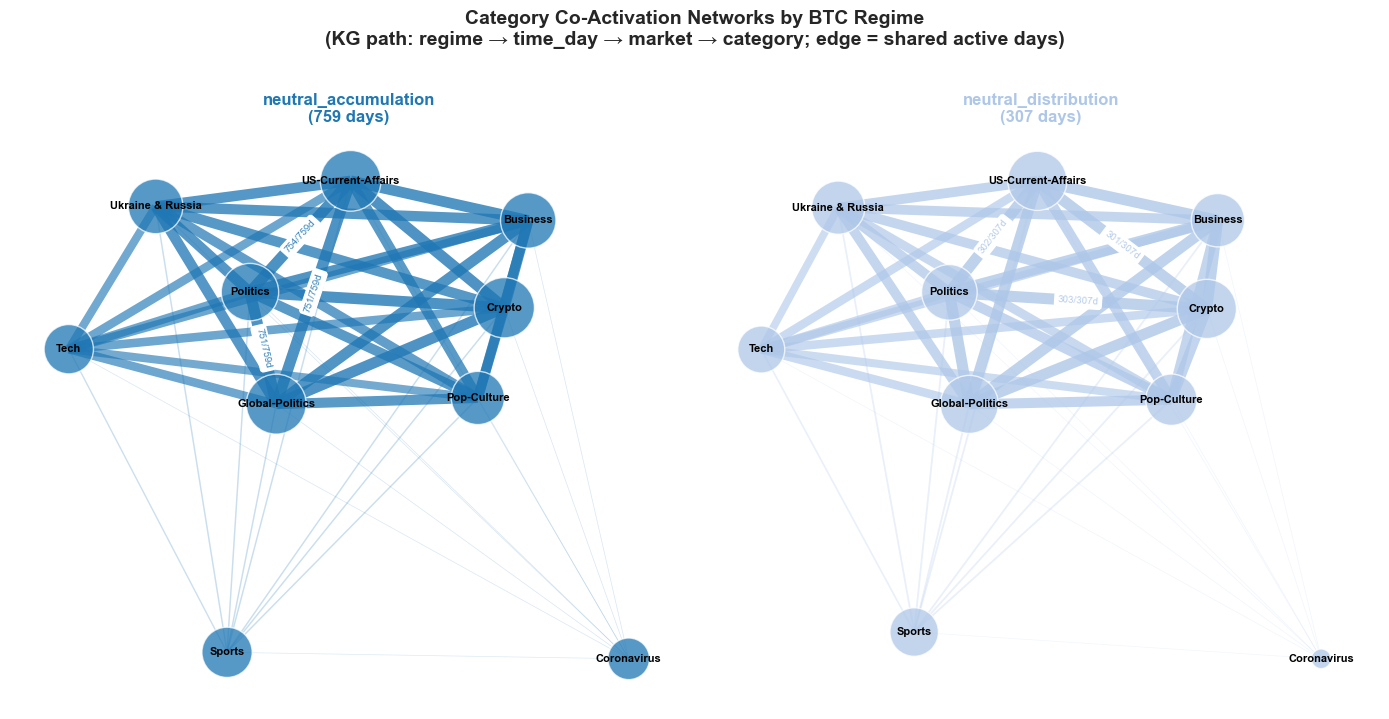


=== Cross-Regime Structural Shift: Category Pair Co-Activation ===
Top 10 category pairs with largest co-activation shift across regimes:


regime,neutral_accumulation,neutral_distribution,max_diff
pair,,,
Politics ↔ Ukraine & Russia,0.933,0.873,0.060
US-Current-Affairs ↔ Ukraine & Russia,0.933,0.873,0.060
Global-Politics ↔ Ukraine & Russia,0.933,0.873,0.060
Business ↔ Ukraine & Russia,0.926,0.866,0.060
Tech ↔ Ukraine & Russia,0.733,0.678,0.055
Crypto ↔ Ukraine & Russia,0.924,0.870,0.054
Pop-Culture ↔ Ukraine & Russia,0.850,0.798,0.052
Crypto ↔ Sports,0.133,0.163,0.030
Global-Politics ↔ Sports,0.133,0.163,0.030


In [8]:
# Category Co-Activation Networks by Regime
if "raw_kg" not in globals():
    raise RuntimeError("raw_kg is not available. Run KG construction cell first.")

from matplotlib.lines import Line2D
from itertools import combinations

# 1) Traverse KG: for each regime, collect category co-activation via time_day → market → category paths
regime_nodes_list = [n for n, d in raw_kg.nodes(data=True) if d.get("node_type") == "regime"]
# 1) Collect category co-activation per regime
regime_cat_cooccur = {}  # regime -> {(cat_a, cat_b): count}
regime_cat_volume = {}   # regime -> {cat: total_volume}
regime_day_counts = {}   # regime -> n_days

for r_node in regime_nodes_list:
    regime = raw_kg.nodes[r_node].get("regime", "?")
    regime_cat_cooccur[regime] = {}
    regime_cat_volume[regime] = {}
    regime_day_counts[regime] = 0

    # Get all time_day nodes for this regime
    t_days = [n for n in raw_kg.neighbors(r_node) if raw_kg.nodes[n].get("node_type") == "time_day"]
    regime_day_counts[regime] = len(t_days)

    for t_node in t_days:
        # Collect categories active on this day via market edges
        day_cats = {}  # cat -> volume on this day
        for m_node in raw_kg.neighbors(t_node):
            if raw_kg.nodes[m_node].get("node_type") != "market":
                continue
            edge_data = raw_kg.get_edge_data(t_node, m_node) or {}
            vol = float(edge_data.get("volume", 0))

            for c_nbr in raw_kg.neighbors(m_node):
                if raw_kg.nodes[c_nbr].get("node_type") == "category":
                    cat = raw_kg.nodes[c_nbr].get("category", "?")
                    day_cats[cat] = day_cats.get(cat, 0) + vol

        # Accumulate category volumes
        for cat, vol in day_cats.items():
            regime_cat_volume[regime][cat] = regime_cat_volume[regime].get(cat, 0) + vol

        # Category co-activation: pairs of categories active on the same day
        active_cats = sorted(day_cats.keys())
        for a, b in combinations(active_cats, 2):
            pair = (a, b)
            regime_cat_cooccur[regime][pair] = regime_cat_cooccur[regime].get(pair, 0) + 1

# 2) Build category co-activation graph for each regime
TARGET_REGIMES = ["neutral_accumulation", "neutral_distribution", "overheated_distribution"]
# Filter to regimes with enough data
TARGET_REGIMES = [r for r in TARGET_REGIMES if regime_day_counts.get(r, 0) >= 10]
if not TARGET_REGIMES:
    TARGET_REGIMES = sorted(regime_day_counts, key=regime_day_counts.get, reverse=True)[:3]

REGIME_COLORS = {
    "overheated_distribution": "#d62728",
    "overheated_accumulation": "#ff7f0e",
    "neutral_distribution": "#aec7e8",
    "neutral_accumulation": "#1f77b4",
    "undervalued": "#2ca02c",
}

# Top categories by overall volume to keep graphs readable
all_cat_vol = {}
for regime in TARGET_REGIMES:
    for cat, vol in regime_cat_volume.get(regime, {}).items():
        all_cat_vol[cat] = all_cat_vol.get(cat, 0) + vol
TOP_N_CATS = 12
top_cats = sorted(all_cat_vol, key=all_cat_vol.get, reverse=True)[:TOP_N_CATS]

# 3) Plot: one network per regime, side by side
n_regimes = len(TARGET_REGIMES)
fig, axes = plt.subplots(1, n_regimes, figsize=(7 * n_regimes, 7))
if n_regimes == 1:
    axes = [axes]

for idx, regime in enumerate(TARGET_REGIMES):
    ax = axes[idx]
    cooccur = regime_cat_cooccur.get(regime, {})
    cat_vol = regime_cat_volume.get(regime, {})
    n_days = regime_day_counts.get(regime, 1)

    # Build networkx graph
    G = nx.Graph()
    for cat in top_cats:
        if cat in cat_vol:
            G.add_node(cat, volume=cat_vol[cat])

    # Add edges (co-occurrence normalized by days)
    max_cooccur = 1
    for (a, b), count in cooccur.items():
        if a in top_cats and b in top_cats:
            # Normalize: fraction of days both categories are active together
            strength = count / n_days
            G.add_edge(a, b, weight=strength, raw_count=count)
            max_cooccur = max(max_cooccur, count)

    if G.number_of_nodes() == 0:
        ax.text(0.5, 0.5, f"No data for {regime}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(regime)
        continue

    # Layout
    pos = nx.spring_layout(G, k=2.0, iterations=60, seed=42, weight="weight")

    # Node sizes proportional to log volume
    node_sizes = []
    for n in G.nodes():
        vol = G.nodes[n].get("volume", 1)
        node_sizes.append(max(200, min(3000, 200 + np.log1p(vol) * 80)))

    # Edge widths proportional to co-occurrence strength
    edge_widths = []
    edge_alphas = []
    for u, v, d in G.edges(data=True):
        raw = d.get("raw_count", 1)
        w = max(0.5, min(8.0, (raw / max_cooccur) * 8.0))
        edge_widths.append(w)
        edge_alphas.append(min(0.8, 0.15 + (raw / max_cooccur) * 0.65))

    # Draw
    regime_color = REGIME_COLORS.get(regime, "#888888")

    nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths, alpha=edge_alphas,
                           edge_color=regime_color)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                           node_color=regime_color, alpha=0.75,
                           linewidths=1, edgecolors="white")
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight="bold")

    # Edge labels for top 3 strongest connections
    edge_list = sorted(G.edges(data=True), key=lambda x: x[2].get("raw_count", 0), reverse=True)
    top_edge_labels = {}
    for u, v, d in edge_list[:3]:
        top_edge_labels[(u, v)] = f"{d['raw_count']}/{n_days}d"
    nx.draw_networkx_edge_labels(G, pos, edge_labels=top_edge_labels, ax=ax,
                                  font_size=7, font_color=regime_color, alpha=0.9)

    ax.set_title(f"{regime}\n({n_days} days)", fontsize=12, fontweight="bold",
                 color=regime_color)
    ax.axis("off")

fig.suptitle("Category Co-Activation Networks by BTC Regime\n"
             "(KG path: regime → time_day → market → category; edge = shared active days)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "kg_category_coactivation_by_regime.png", dpi=150, bbox_inches="tight")
plt.show()

# 4) Quantitative insight: which category pairs change most across regimes?
pair_regime_df_rows = []
print("\n=== Cross-Regime Structural Shift: Category Pair Co-Activation ===")
# 4) Cross-regime co-activation shift
for regime in TARGET_REGIMES:
    cooccur = regime_cat_cooccur.get(regime, {})
    n_days = regime_day_counts.get(regime, 1)
    for (a, b), count in cooccur.items():
        if a in top_cats and b in top_cats:
            pair_regime_df_rows.append({
                "pair": f"{a} ↔ {b}",
                "regime": regime,
                "co_days": count,
                "co_rate": count / n_days,
            })

pair_df = pd.DataFrame(pair_regime_df_rows)
if not pair_df.empty and len(TARGET_REGIMES) >= 2:
    pivot_rate = pair_df.pivot(index="pair", columns="regime", values="co_rate").fillna(0)
    # Find pairs with largest regime-dependent variation
    pivot_rate["max_diff"] = pivot_rate.max(axis=1) - pivot_rate.min(axis=1)
    pivot_rate = pivot_rate.sort_values("max_diff", ascending=False)

    print("Top 10 category pairs with largest co-activation shift across regimes:")
    display(pivot_rate.head(10).round(3))

### KG Visualization Interpretation

**Finding: Category co-activation structure is regime-invariant.**

- The maximum co-activation rate difference across regimes is only **0.060 (6%p)**, meaning the category network topology is nearly identical regardless of BTC on-chain regime.
- The top 7 most-shifted pairs are all driven by a single category ("Ukraine & Russia"), reflecting temporal availability rather than structural regime dependence.
- Both regime networks show the same densely connected core (Politics, Global-Politics, Crypto, Business, US-Current-Affairs) with identical peripheral positions (Sports, Coronavirus).
- This confirms the Executive Summary conclusion from a **graph-structural perspective**: KG construction does not reveal regime-dependent relationships that simple tabular analysis cannot.

=== Odds Delta ↔ BTC Return Correlation ===


,feature,horizon,corr,n_obs
0,mean_abs_delta_odds,0,-0.013473,1065
1,mean_abs_delta_odds,1,-0.036010,1064
2,mean_abs_delta_odds,3,0.022133,1062
3,mean_abs_delta_odds,7,-0.020646,1058
4,max_abs_delta_odds,0,-0.026070,1065
5,max_abs_delta_odds,1,-0.035867,1064
6,max_abs_delta_odds,3,-0.024790,1062
7,max_abs_delta_odds,7,-0.006220,1058
8,mean_intraday_vol,0,-0.007399,1065
9,mean_intraday_vol,1,0.001729,1064


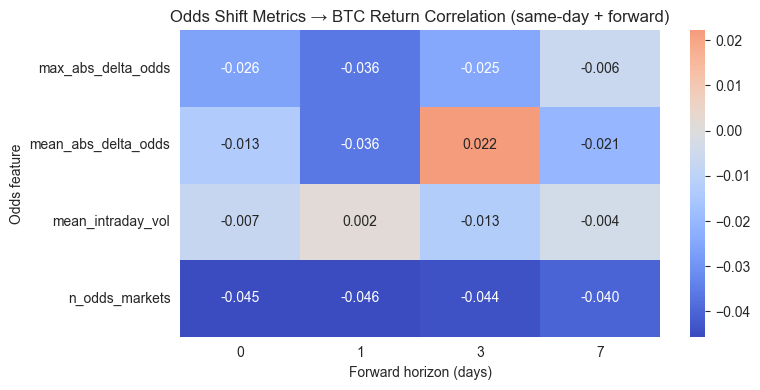

In [9]:
# Collect daily aggregated odds metrics from KG edges
_daily_odds_rows = []
for t_node in time_day_nodes:
    t_data = raw_kg.nodes[t_node]
    btc_ret = t_data.get("btc_return", np.nan)
    if pd.isna(btc_ret):
        continue

    neighbors = [n for n in raw_kg.neighbors(t_node) if raw_kg.nodes[n].get("node_type") == "market"]
    if not neighbors:
        continue

    day_deltas = []
    day_intraday_vols = []
    for m in neighbors:
        ed = raw_kg.get_edge_data(t_node, m) or {}
        if ed.get("has_odds"):
            day_deltas.append(ed.get("mean_abs_delta_odds", 0))
            day_intraday_vols.append(ed.get("mean_intraday_vol", 0))

    if day_deltas:
        _daily_odds_rows.append({
            "date": t_data.get("date"),
            "btc_return": btc_ret,
            "mean_abs_delta_odds": np.mean(day_deltas),
            "max_abs_delta_odds": np.max(day_deltas),
            "mean_intraday_vol": np.mean(day_intraday_vols),
            "n_odds_markets": len(day_deltas),
        })

odds_btc_df = pd.DataFrame(_daily_odds_rows).sort_values("date").reset_index(drop=True)

if len(odds_btc_df) >= 30:
    # Same-day and forward correlations
    odds_features = ["mean_abs_delta_odds", "max_abs_delta_odds", "mean_intraday_vol", "n_odds_markets"]
    horizons = [0, 1, 3, 7]
    corr_rows = []
    for feat in odds_features:
        for h in horizons:
            target = "btc_return" if h == 0 else f"btc_fwd_{h}"
            work = odds_btc_df[[feat, "btc_return"]].copy()
            if h > 0:
                work[target] = work["btc_return"].shift(-h)
            valid = work[[feat, target]].dropna()
            corr = float(valid[feat].corr(valid[target])) if len(valid) >= 30 else np.nan
            corr_rows.append({"feature": feat, "horizon": h, "corr": corr, "n_obs": len(valid)})

    odds_corr_df = pd.DataFrame(corr_rows)
    pivot = odds_corr_df.pivot(index="feature", columns="horizon", values="corr")

    print("=== Odds Delta ↔ BTC Return Correlation ===")
    display(odds_corr_df)

    plt.figure(figsize=(8, 4))
    sns.heatmap(pivot.fillna(0), annot=True, fmt=".3f", cmap="coolwarm", center=0)
    plt.title("Odds Shift Metrics → BTC Return Correlation (same-day + forward)")
    plt.xlabel("Forward horizon (days)")
    plt.ylabel("Odds feature")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "improved_kg_odds_btc_corr.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Insufficient data for odds-BTC correlation: {len(odds_btc_df)} rows (need 30+)")

## KG Investment Signal Engine (BTC-linked, KG-first)

This section upgrades the KG from structural diagnostics to actionable investment-signal analysis.

Narrative order (reordered for investment decision flow):
1. Slug-level BTC reaction patterns
2. Category-level BTC sensitivity
3. Polymarket activity -> BTC return relationship
4. Regime-wise change in Polymarket -> BTC relationship
5. DCA overlay signal generation

### 1) Slugs with the Largest Volume-Intensity Impact

Measure slug impact as the deviation of slug-level `volume per market` from the same-day market baseline.

c:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-0

,event_slug,active_days,mean_abs_vol_lift,max_abs_vol_lift,mean_signed_vol_lift,mean_abs_trd_lift,avg_markets,avg_volume,btc_ret_corr,impact_score
37942,will-trump-resign-today,2,9.704778e+06,1.937799e+07,9.704778e+06,2222.407270,1.000000,9.718069e+06,NaN,1.066179e+07
25580,fed-decision-in-december,133,9.057933e+05,6.316301e+06,9.004090e+05,979.170004,3.977444,3.644630e+06,-0.085572,4.436431e+06
25587,fed-decision-in-october,135,8.687773e+05,2.174170e+07,8.616778e+05,713.084317,3.955556,3.485190e+06,-0.124904,4.268003e+06
26379,people-power-party-ppp-presidential-candidate,30,1.226617e+06,3.001093e+07,1.216431e+06,99.153298,9.466667,1.885362e+06,-0.172130,4.212187e+06
25588,fed-decision-in-september,133,8.196484e+05,2.363471e+07,8.151771e+05,674.193800,4.000000,3.314575e+06,0.027205,4.014507e+06
37652,will-trump-deploy-national-guard-in-dc-by-monday,6,1.437542e+06,4.751212e+06,1.436699e+06,570.937411,1.000000,1.445587e+06,NaN,2.797328e+06
26356,over-1pt8b-committed-to-the-megaeth-public-sale,6,1.340261e+06,4.855841e+06,1.333557e+06,1755.556003,4.666667,9.583902e+06,NaN,2.608028e+06
25582,fed-decision-in-july,133,5.079008e+05,1.096081e+07,4.946935e+05,423.126811,4.000000,2.045118e+06,-0.018591,2.487617e+06
37802,will-trump-lower-tariffs-on-china-in-april,13,8.213578e+05,4.777526e+06,8.148041e+05,343.130967,1.000000,8.286967e+05,NaN,2.167610e+06
25583,fed-decision-in-june,131,3.882389e+05,8.343662e+06,3.850373e+05,261.244803,4.000000,1.592023e+06,-0.029832,1.895694e+06


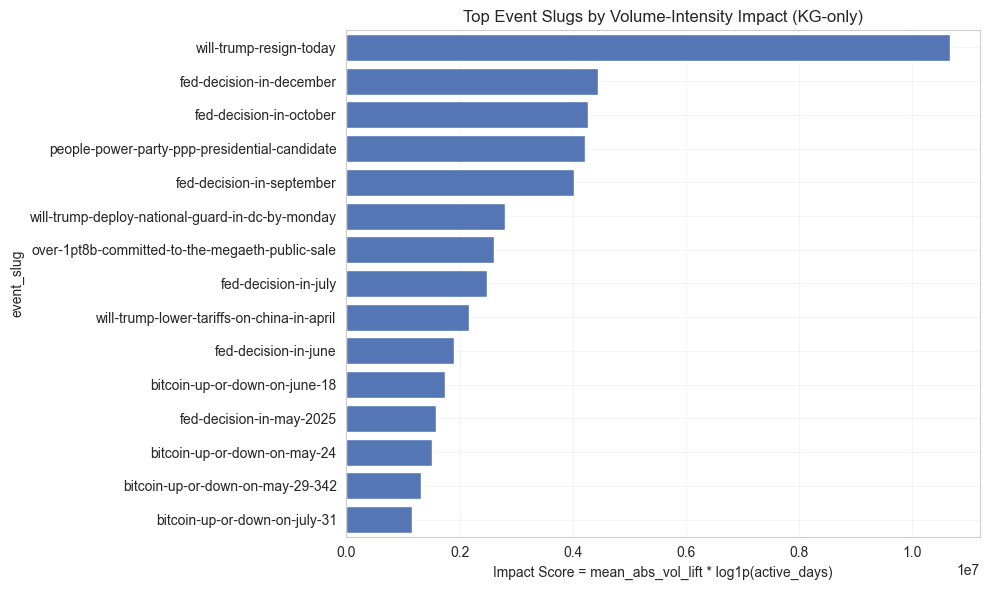

KG daily table rows: 1066 | slug-day rows: 289326


In [10]:
# 1) Slugs with the largest volume-intensity impact (pure KG, no BTC dataframe merge)
if "raw_kg" not in globals():
    raise RuntimeError("raw_kg is not available. Run KG construction cell first.")


def _collect_market_neighbors(g: nx.Graph, t_node: str) -> list[str]:
    return [n for n in g.neighbors(t_node) if g.nodes[n].get("node_type") == "market"]


def _market_category(g: nx.Graph, m_node: str) -> str:
    for nbr in g.neighbors(m_node):
        if g.nodes[nbr].get("node_type") == "category":
            return str(g.nodes[nbr].get("category", "Unknown"))
    return "Unknown"


def _market_event_slug(g: nx.Graph, m_node: str) -> str:
    for nbr in g.neighbors(m_node):
        if g.nodes[nbr].get("node_type") == "event":
            return str(g.nodes[nbr].get("event_slug", "Unknown"))
    return "Unknown"


def build_daily_tables_from_kg(g: nx.Graph) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    time_rows = []
    market_rows = []
    slug_rows = []

    time_nodes = sorted(
        [n for n, d in g.nodes(data=True) if d.get("node_type") == "time_day"],
        key=lambda x: g.nodes[x].get("date", "")
    )

    for t_node in time_nodes:
        t_date = pd.to_datetime(g.nodes[t_node].get("date"))
        btc_price = g.nodes[t_node].get("btc_price", np.nan)
        btc_return = g.nodes[t_node].get("btc_return", np.nan)

        markets = _collect_market_neighbors(g, t_node)
        if len(markets) == 0:
            continue

        total_volume = 0.0
        total_trade_count = 0.0
        categories = set()
        slug_acc = {}

        for m_node in markets:
            edge = g.get_edge_data(t_node, m_node) or {}
            volume = float(edge.get("volume", 0.0))
            trade_count = float(edge.get("trade_count", 0.0))

            total_volume += volume
            total_trade_count += trade_count

            category = _market_category(g, m_node)
            event_slug = _market_event_slug(g, m_node)
            categories.add(category)

            market_rows.append({
                "date": t_date,
                "t_node": t_node,
                "market_node": m_node,
                "event_slug": event_slug,
                "category": category,
                "volume": volume,
                "trade_count": trade_count,
                "btc_return": btc_return,
            })

            if event_slug not in slug_acc:
                slug_acc[event_slug] = {"sum_volume": 0.0, "sum_trade_count": 0.0, "count": 0}
            slug_acc[event_slug]["sum_volume"] += volume
            slug_acc[event_slug]["sum_trade_count"] += trade_count
            slug_acc[event_slug]["count"] += 1

        time_rows.append({
            "date": t_date,
            "time_day": str(g.nodes[t_node].get("date")),
            "t_node": t_node,
            "btc_price": btc_price,
            "btc_return": btc_return,
            "total_volume": total_volume,
            "total_trade_count": total_trade_count,
            "n_markets": len(markets),
            "n_categories": len(categories),
            "baseline_vol_per_mkt": (total_volume / len(markets)) if len(markets) > 0 else np.nan,
            "baseline_trd_per_mkt": (total_trade_count / len(markets)) if len(markets) > 0 else np.nan,
        })

        for slug, acc in slug_acc.items():
            slug_rows.append({
                "date": t_date,
                "t_node": t_node,
                "event_slug": slug,
                "n_markets": acc["count"],
                "total_volume": acc["sum_volume"],
                "total_trade_count": acc["sum_trade_count"],
                "slug_vol_per_mkt": (acc["sum_volume"] / acc["count"]) if acc["count"] > 0 else np.nan,
                "slug_trd_per_mkt": (acc["sum_trade_count"] / acc["count"]) if acc["count"] > 0 else np.nan,
                "btc_return": btc_return,
            })

    return pd.DataFrame(time_rows), pd.DataFrame(market_rows), pd.DataFrame(slug_rows)


kg_time_df, kg_market_df, kg_slug_df = build_daily_tables_from_kg(raw_kg)

kg_slug_df = kg_slug_df.merge(
    kg_time_df[["date", "baseline_vol_per_mkt", "baseline_trd_per_mkt"]],
    on="date",
    how="left",
)
kg_slug_df["volume_intensity_lift"] = kg_slug_df["slug_vol_per_mkt"] - kg_slug_df["baseline_vol_per_mkt"]
kg_slug_df["trade_intensity_lift"] = kg_slug_df["slug_trd_per_mkt"] - kg_slug_df["baseline_trd_per_mkt"]

slug_impact_df = (
    kg_slug_df.groupby("event_slug", as_index=False)
    .agg(
        active_days=("date", "nunique"),
        mean_abs_vol_lift=("volume_intensity_lift", lambda s: float(np.abs(s).mean())),
        max_abs_vol_lift=("volume_intensity_lift", lambda s: float(np.abs(s).max())),
        mean_signed_vol_lift=("volume_intensity_lift", "mean"),
        mean_abs_trd_lift=("trade_intensity_lift", lambda s: float(np.abs(s).mean())),
        avg_markets=("n_markets", "mean"),
        avg_volume=("total_volume", "mean"),
    )
)

corr_rows = []
for slug, sub in kg_slug_df.groupby("event_slug"):
    valid = sub[["volume_intensity_lift", "btc_return"]].dropna()
    corr = float(valid["volume_intensity_lift"].corr(valid["btc_return"])) if len(valid) >= 20 else np.nan
    corr_rows.append({"event_slug": slug, "btc_ret_corr": corr})

corr_df = pd.DataFrame(corr_rows)
slug_impact_df = slug_impact_df.merge(corr_df, on="event_slug", how="left")
slug_impact_df["impact_score"] = slug_impact_df["mean_abs_vol_lift"] * np.log1p(slug_impact_df["active_days"])
slug_impact_df = slug_impact_df.sort_values("impact_score", ascending=False)

top_slug_impact = slug_impact_df.head(15).copy()
display(top_slug_impact)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_slug_impact, x="impact_score", y="event_slug", color="#4472c4")
plt.title("Top Event Slugs by Volume-Intensity Impact (KG-only)")
plt.xlabel("Impact Score = mean_abs_vol_lift * log1p(active_days)")
plt.ylabel("event_slug")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "raw_kg_slug_volume_impact.png", dpi=150, bbox_inches="tight")
plt.show()

print("KG daily table rows:", len(kg_time_df), "| slug-day rows:", len(kg_slug_df))

In [11]:
# Graph-importance ranking for slugs (structure + activity + BTC linkage)
if "raw_kg" not in globals() or "kg_slug_df" not in globals() or "slug_impact_df" not in globals():
    raise RuntimeError("Required artifacts are missing. Run Cell 8 first.")

if slug_impact_df is None or slug_impact_df.empty:
    print("Skip graph-importance slug analysis: slug impact table is empty.")
    rank_df = pd.DataFrame()
else:
    struct_rows = []
    for n, d in raw_kg.nodes(data=True):
        if d.get("node_type") != "event":
            continue
        slug = str(d.get("event_slug", "")).strip()
        if slug == "" or slug.lower() == "unknown":
            continue

        market_neighbors = [m for m in raw_kg.neighbors(n) if raw_kg.nodes[m].get("node_type") == "market"]
        t_nodes = set()
        for m in market_neighbors:
            for nbr in raw_kg.neighbors(m):
                if raw_kg.nodes[nbr].get("node_type") == "time_day":
                    t_nodes.add(nbr)

        struct_rows.append({
            "event_slug": slug,
            "event_degree": len(market_neighbors),
            "day_coverage": len(t_nodes),
        })

    struct_df = pd.DataFrame(struct_rows)
    if struct_df.empty:
        raise RuntimeError("No valid event_slug nodes found for structural ranking.")

    activity_df = (
        kg_slug_df.copy()
        .assign(event_slug=lambda d: d["event_slug"].astype(str).str.strip())
    )
    activity_df = activity_df[(activity_df["event_slug"] != "") & (activity_df["event_slug"].str.lower() != "unknown")]

    activity_agg = (
        activity_df.groupby("event_slug", as_index=False)
        .agg(
            active_days=("date", "nunique"),
            total_volume=("total_volume", "sum"),
            total_trade_count=("total_trade_count", "sum"),
        )
    )

    btc_rows = []
    for slug, sub in activity_df.groupby("event_slug"):
        valid = sub[["volume_intensity_lift", "btc_return"]].dropna() if "volume_intensity_lift" in sub.columns else pd.DataFrame()
        corr_val = float(valid["volume_intensity_lift"].corr(valid["btc_return"])) if len(valid) >= 20 else np.nan
        btc_rows.append({"event_slug": slug, "abs_btc_corr": abs(corr_val) if pd.notna(corr_val) else 0.0})

    btc_link_df = pd.DataFrame(btc_rows)
    activity_agg = activity_agg.merge(btc_link_df, on="event_slug", how="left")

    impact_df = slug_impact_df[["event_slug", "impact_score", "mean_abs_vol_lift"]].copy()
    impact_df["event_slug"] = impact_df["event_slug"].astype(str).str.strip()
    impact_df = impact_df[(impact_df["event_slug"] != "") & (impact_df["event_slug"].str.lower() != "unknown")]

    rank_df = (
        struct_df
        .merge(activity_agg, on="event_slug", how="inner")
        .merge(impact_df, on="event_slug", how="left")
    )

    for col in ["impact_score", "total_volume", "total_trade_count", "event_degree", "day_coverage", "abs_btc_corr"]:
        if col not in rank_df.columns:
            rank_df[col] = 0.0
        rank_df[col] = rank_df[col].fillna(0.0)

    rank_df["log_volume"] = np.log1p(rank_df["total_volume"])
    rank_df["log_trade"] = np.log1p(rank_df["total_trade_count"] )

    def minmax(s: pd.Series) -> pd.Series:
        mn, mx = float(s.min()), float(s.max())
        if mx - mn <= 1e-12:
            return pd.Series(np.zeros(len(s)), index=s.index)
        return (s - mn) / (mx - mn)

    rank_df["importance_score"] = (
        0.30 * minmax(rank_df["impact_score"])
        + 0.20 * minmax(rank_df["log_volume"])
        + 0.15 * minmax(rank_df["log_trade"])
        + 0.15 * minmax(rank_df["event_degree"])
        + 0.10 * minmax(rank_df["day_coverage"])
        + 0.10 * minmax(rank_df["abs_btc_corr"] )
    )

    rank_df = rank_df.sort_values("importance_score", ascending=False).reset_index(drop=True)
    top_slug_graph = rank_df.iloc[0].copy()

    display(rank_df.head(15))

    print("Most important slug (graph composite):", top_slug_graph["event_slug"])
    print(
        "Why important -> "
        f"importance={top_slug_graph['importance_score']:.4f}, "
        f"impact_score={top_slug_graph['impact_score']:.4f}, "
        f"event_degree={int(top_slug_graph['event_degree'])}, "
        f"day_coverage={int(top_slug_graph['day_coverage'])}, "
        f"total_volume={top_slug_graph['total_volume']:.2f}, "
        f"abs_btc_corr={top_slug_graph['abs_btc_corr']:.4f}"
    )

c:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-0

,event_slug,event_degree,day_coverage,active_days,total_volume,total_trade_count,abs_btc_corr,impact_score,mean_abs_vol_lift,log_volume,log_trade,importance_score
0,will-trump-resign-today,1,2,2,1.943614e+07,4522.0,0.000000,1.066179e+07,9.704778e+06,16.782645,8.416931,0.563659
1,fed-decision-in-december,4,133,133,4.847358e+08,541570.0,0.085572,4.436431e+06,9.057933e+05,19.999114,13.202229,0.520976
2,fed-decision-in-october,4,135,135,4.705006e+08,395933.0,0.124904,4.268003e+06,8.687773e+05,19.969308,12.889003,0.519155
3,fed-decision-in-september,4,133,133,4.408385e+08,382004.0,0.027205,4.014507e+06,8.196484e+05,19.904189,12.853189,0.494711
4,people-power-party-ppp-presidential-candidate,11,30,30,5.656086e+07,41404.0,0.172130,4.212187e+06,1.226617e+06,17.850828,10.631157,0.473467
5,fed-decision-in-july,4,133,133,2.720007e+08,240913.0,0.018591,2.487617e+06,5.079008e+05,19.421315,12.392195,0.440282
6,what-price-will-bitcoin-hit-in-2025,28,367,367,2.727767e+07,73154.0,0.017942,7.204474e+04,1.219427e+04,17.121579,11.200336,0.434046
7,democratic-presidential-nominee-2028,38,171,171,3.963287e+07,55302.0,0.107109,7.028075e+04,1.365339e+04,17.495169,10.920582,0.433034
8,new-york-city-mayoral-election,12,198,198,2.310481e+08,315540.0,0.120431,5.139587e+05,9.709599e+04,19.258136,12.662044,0.432987
9,chile-presidential-election,16,224,224,1.120443e+08,106421.0,0.198580,2.064738e+05,3.812223e+04,18.534405,11.575168,0.431311


Most important slug (graph composite): will-trump-resign-today
Why important -> importance=0.5637, impact_score=10661788.5037, event_degree=1, day_coverage=2, total_volume=19436137.57, abs_btc_corr=0.0000


### 1.1) Graph-Importance Slug (Structure + Volume/Trade + BTC Linkage)

This cell identifies the most important `event_slug` using a composite score that combines:
- structural reach (`event_degree`, `day_coverage`)
- activity scale (`total_volume`, `total_trade_count`)
- volume-intensity impact dynamics (`impact_score`)
- BTC linkage (`abs_btc_corr`)

### 2) Category-Level BTC Sensitivity (Volume/Trade/Breadth)

Estimate category sensitivity using category-level volume/trade/breadth dynamics and BTC-return linkage (same-day and forward horizons).

,category,n_obs,corr_strength_btc_same,corr_volume_btc_same,corr_trade_btc_same,mean_fwd_corr_1_3_7,sensitivity_score
1,Coronavirus,49,-0.267733,-0.244725,-0.312251,-0.126443,0.197088
6,Sports,151,0.144990,0.120723,0.141946,0.056090,0.100540
7,Tech,815,-0.070651,-0.063334,-0.083844,-0.007103,0.038877
4,Politics,1066,-0.022860,0.003273,-0.010702,-0.018549,0.020705
9,Ukraine & Russia,976,-0.014369,0.010319,-0.014139,0.015134,0.014751
3,Global-Politics,1052,-0.020849,0.003089,0.008478,-0.006144,0.013496
5,Pop-Culture,961,0.011806,0.029329,0.017029,-0.014251,0.013029
2,Crypto,1051,-0.006416,-0.058293,-0.045539,-0.017217,0.011816
8,US-Current-Affairs,1056,0.009466,-0.035331,-0.039804,-0.005335,0.007400
0,Business,1025,0.002914,-0.004124,-0.011686,-0.006676,0.004795


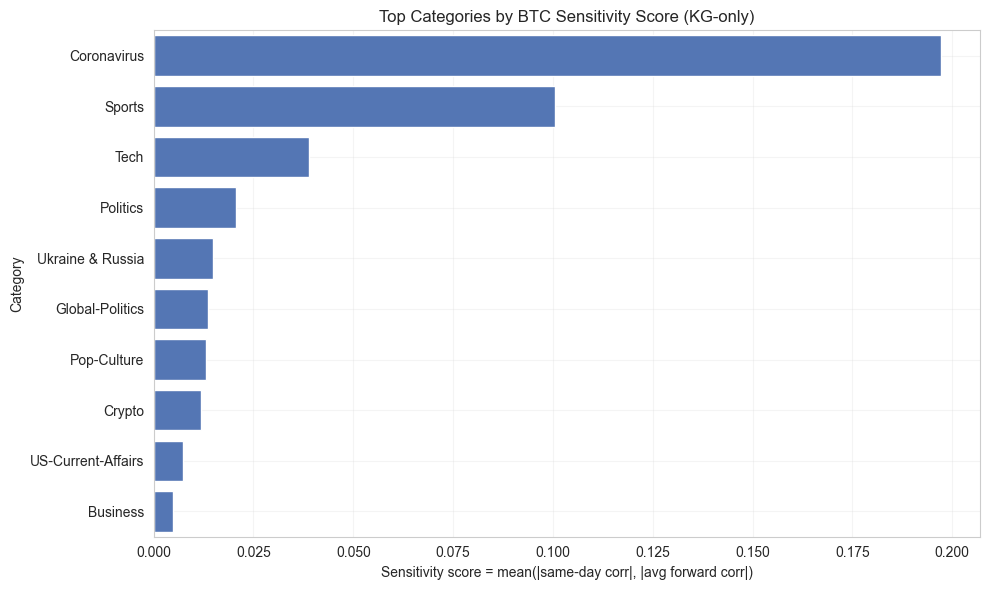

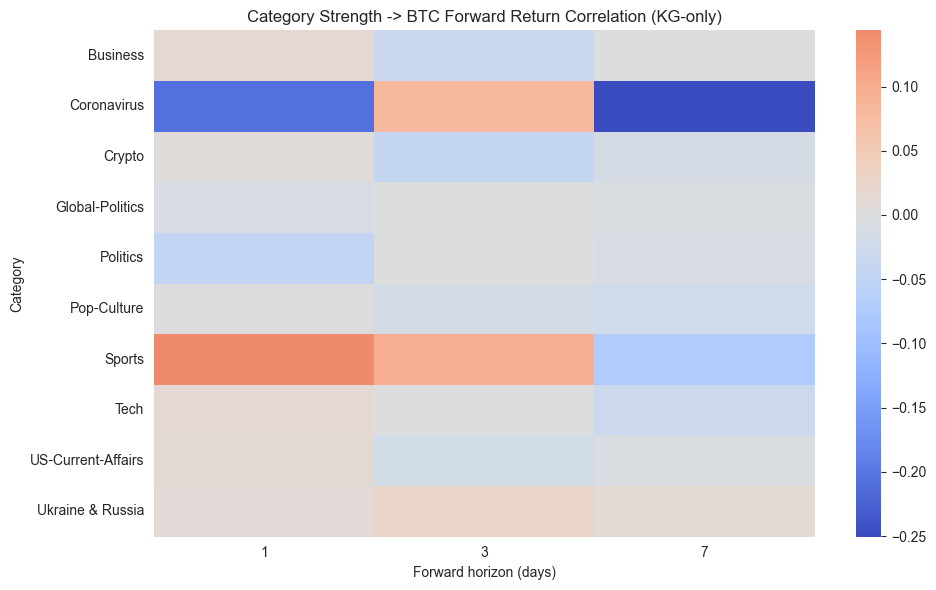

In [12]:
# 2) Category-level BTC sensitivity (KG-only, volume/trade/breadth)
if "kg_market_df" not in globals() or kg_market_df.empty:
    raise RuntimeError("kg_market_df is not available. Run cell 8 first.")

cat_day = (
    kg_market_df.groupby(["date", "category"], as_index=False)
    .agg(
        volume_sum=("volume", "sum"),
        trade_sum=("trade_count", "sum"),
        market_count=("market_node", "nunique"),
        btc_return=("btc_return", "mean"),
    )
    .sort_values(["category", "date"] )
)

def rolling_zscore(series: pd.Series, window: int = 30) -> pd.Series:
    roll_mean = series.rolling(window=window, min_periods=10).mean()
    roll_std = series.rolling(window=window, min_periods=10).std()
    z = (series - roll_mean) / roll_std.replace(0, np.nan)
    return z.fillna(0.0)

cat_day["vol_z"] = cat_day.groupby("category")["volume_sum"].transform(rolling_zscore)
cat_day["trd_z"] = cat_day.groupby("category")["trade_sum"].transform(rolling_zscore)
cat_day["mkt_z"] = cat_day.groupby("category")["market_count"].transform(rolling_zscore)
cat_day["strength_score"] = 0.45 * cat_day["vol_z"] + 0.35 * cat_day["trd_z"] + 0.20 * cat_day["mkt_z"]

same_day_rows = []
for cat, g in cat_day.groupby("category"):
    same_day_rows.append({
        "category": cat,
        "n_obs": len(g),
        "corr_strength_btc_same": float(g["strength_score"].corr(g["btc_return"])) if len(g[["strength_score", "btc_return"]].dropna()) >= 30 else np.nan,
        "corr_volume_btc_same": float(g["volume_sum"].corr(g["btc_return"])) if len(g[["volume_sum", "btc_return"]].dropna()) >= 30 else np.nan,
        "corr_trade_btc_same": float(g["trade_sum"].corr(g["btc_return"])) if len(g[["trade_sum", "btc_return"]].dropna()) >= 30 else np.nan,
    })
same_day_sens = pd.DataFrame(same_day_rows)

horizons = [1, 3, 7]
lead_rows = []
for cat, sub in cat_day.groupby("category"):
    sub = sub.sort_values("date").copy()
    for h in horizons:
        sub[f"btc_fwd_{h}"] = sub["btc_return"].shift(-h)
        valid = sub[["strength_score", f"btc_fwd_{h}"]].dropna()
        lead_corr = float(valid["strength_score"].corr(valid[f"btc_fwd_{h}"])) if len(valid) >= 30 else np.nan
        lead_rows.append({
            "category": cat,
            "horizon_days": h,
            "corr_strength_to_btc_fwd": lead_corr,
            "n_obs": len(valid),
        })

cat_lead_df = pd.DataFrame(lead_rows)
lead_pivot = cat_lead_df.pivot(index="category", columns="horizon_days", values="corr_strength_to_btc_fwd")

cat_sensitivity_df = same_day_sens.merge(
    cat_lead_df.groupby("category", as_index=False)["corr_strength_to_btc_fwd"].mean().rename(columns={"corr_strength_to_btc_fwd": "mean_fwd_corr_1_3_7"}),
    on="category",
    how="left",
)
cat_sensitivity_df["sensitivity_score"] = cat_sensitivity_df[["corr_strength_btc_same", "mean_fwd_corr_1_3_7"]].abs().mean(axis=1)
cat_sensitivity_df = cat_sensitivity_df.sort_values("sensitivity_score", ascending=False)

display(cat_sensitivity_df.head(20))

plt.figure(figsize=(10, 6))
plot_top = cat_sensitivity_df.head(12).copy()
sns.barplot(data=plot_top, x="sensitivity_score", y="category", color="#4472c4")
plt.title("Top Categories by BTC Sensitivity Score (KG-only)")
plt.xlabel("Sensitivity score = mean(|same-day corr|, |avg forward corr|)")
plt.ylabel("Category")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(lead_pivot.fillna(0.0), cmap="coolwarm", center=0)
plt.title("Category Strength -> BTC Forward Return Correlation (KG-only)")
plt.xlabel("Forward horizon (days)")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "raw_kg_category_btc_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

### 3) Polymarket Activity -> BTC Return Correlation (No Active-Ratio)

Quantify whether Polymarket activity metrics (volume/trade count/market breadth) co-move with BTC returns and whether they lead future BTC returns.

,feature,horizon_days,corr,abs_corr,n_obs
8,n_markets,0,-0.047605,0.047605,1066
4,total_trade_count,0,-0.044003,0.044003,1066
0,total_volume,0,-0.038358,0.038358,1066
12,n_categories,0,-0.031664,0.031664,1066
9,n_markets,1,-0.045989,0.045989,1065
13,n_categories,1,-0.033200,0.033200,1065
5,total_trade_count,1,-0.032722,0.032722,1065
1,total_volume,1,-0.020564,0.020564,1065
6,total_trade_count,3,-0.058715,0.058715,1063
10,n_markets,3,-0.046935,0.046935,1063


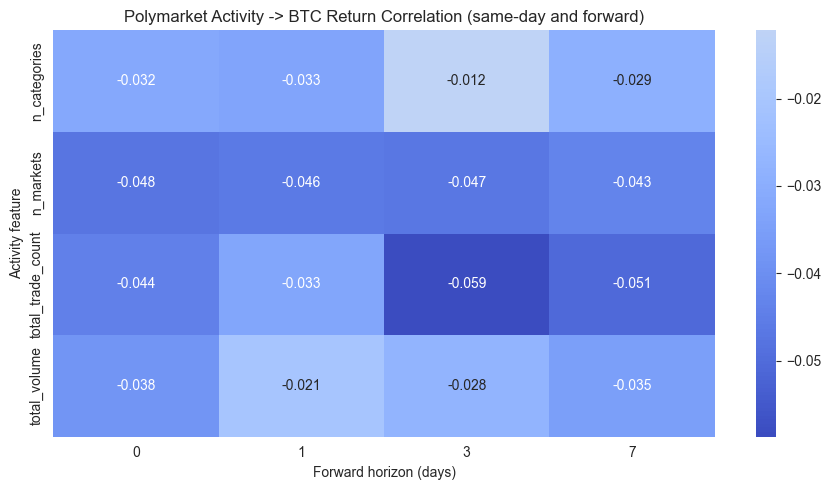

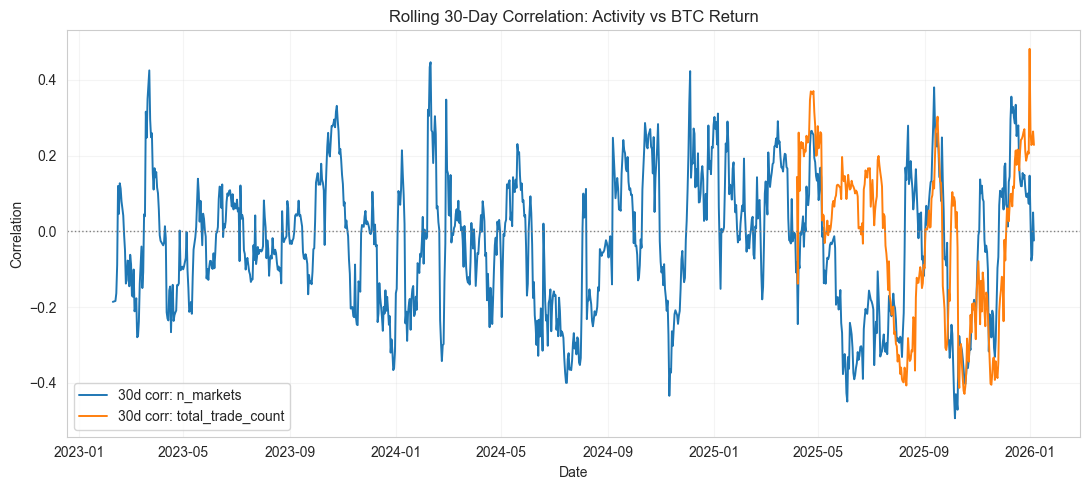

In [13]:
# 3) Polymarket activity -> BTC return correlation (KG-only, no active-ratio)
if "kg_time_df" not in globals() or kg_time_df.empty:
    raise RuntimeError("kg_time_df is not available. Run cell 8 first.")

base_cols = ["date", "btc_return", "total_volume", "total_trade_count", "n_markets", "n_categories"]
available_cols = [c for c in base_cols if c in kg_time_df.columns]
activity_df = (
    kg_time_df[available_cols]
    .dropna(subset=["btc_return"] )
    .sort_values("date")
    .reset_index(drop=True)
)

activity_features = [
    c for c in ["total_volume", "total_trade_count", "n_markets", "n_categories"]
    if c in activity_df.columns
]

if len(activity_features) == 0:
    print("Skip activity->BTC analysis: required activity features are unavailable in raw-only data.")
    activity_corr_df = pd.DataFrame()
else:
    horizons = [0, 1, 3, 7]
    rows = []
    for feat in activity_features:
        for h in horizons:
            target_col = "btc_return" if h == 0 else f"btc_fwd_{h}"
            work = activity_df[[feat, "btc_return"]].copy()
            if h > 0:
                work[target_col] = work["btc_return"].shift(-h)
            valid = work[[feat, target_col]].dropna()
            corr = float(valid[feat].corr(valid[target_col])) if len(valid) >= 30 else np.nan
            rows.append({
                "feature": feat,
                "horizon_days": h,
                "corr": corr,
                "abs_corr": abs(corr) if pd.notna(corr) else np.nan,
                "n_obs": len(valid),
            })

    activity_corr_df = pd.DataFrame(rows)
    display(activity_corr_df.sort_values(["horizon_days", "abs_corr"], ascending=[True, False]))

    pivot_corr = activity_corr_df.pivot(index="feature", columns="horizon_days", values="corr")

    plt.figure(figsize=(9, 5))
    sns.heatmap(pivot_corr.fillna(0.0), annot=True, fmt=".3f", cmap="coolwarm", center=0)
    plt.title("Polymarket Activity -> BTC Return Correlation (same-day and forward)")
    plt.xlabel("Forward horizon (days)")
    plt.ylabel("Activity feature")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "raw_kg_activity_btc_corr_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

    same_day_rank = activity_corr_df[activity_corr_df["horizon_days"] == 0].sort_values("abs_corr", ascending=False)
    top_feats = same_day_rank["feature"].head(2).tolist()

    if len(top_feats) > 0:
        roll_df = activity_df[["date", "btc_return"] + top_feats].copy()
        for feat in top_feats:
            roll_df[f"roll_corr_{feat}"] = roll_df[feat].rolling(30, min_periods=15).corr(roll_df["btc_return"] )

        plt.figure(figsize=(11, 5))
        for feat in top_feats:
            plt.plot(roll_df["date"], roll_df[f"roll_corr_{feat}"], label=f"30d corr: {feat}", linewidth=1.4)
        plt.axhline(0, color="gray", linestyle=":", linewidth=1)
        plt.title("Rolling 30-Day Correlation: Activity vs BTC Return")
        plt.xlabel("Date")
        plt.ylabel("Correlation")
        plt.legend()
        plt.grid(alpha=0.2)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "raw_kg_activity_btc_rolling_corr.png", dpi=150, bbox_inches="tight")
        plt.show()

### 4) Regime Shift, 5) DCA Overlay (Walk-Forward)

Test regime-wise relationship shifts between Polymarket activity and BTC returns, then validate a DCA overlay with walk-forward splits to check overfitting risk.

,regime,feature,corr_same_day,n_obs
0,Bear (<= -1%),total_volume,0.041638,287
1,Bear (<= -1%),total_trade_count,-0.001257,287
2,Bear (<= -1%),n_markets,0.040662,287
3,Bull (>= +1%),total_volume,-0.087146,318
4,Bull (>= +1%),total_trade_count,-0.089402,318
5,Bull (>= +1%),n_markets,-0.147661,318
6,Neutral (-1%~+1%),total_volume,0.044399,461
7,Neutral (-1%~+1%),total_trade_count,0.061801,461
8,Neutral (-1%~+1%),n_markets,0.060990,461


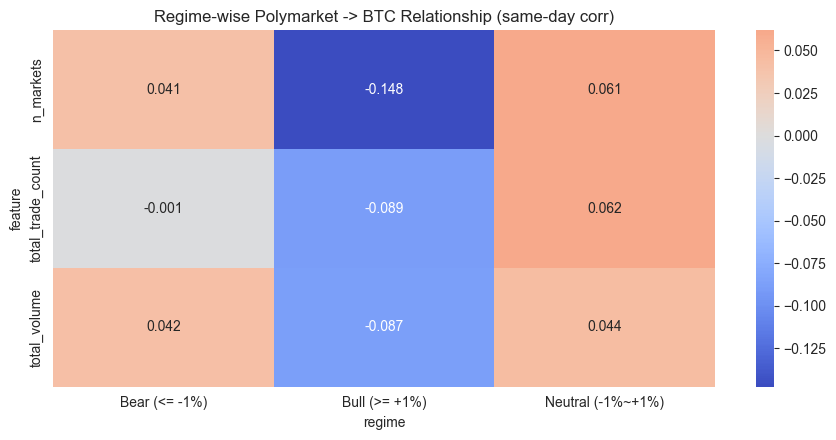

,fold,train_start,train_end,test_start,test_end,dip_coef,pressure_coef,pressure_thr,train_delta_pnl_pct,test_delta_pnl_pct,test_base_pnl_pct,test_overlay_pnl_pct,test_cost_advantage,test_signal_rate,test_mean_multiplier
0,1,2023-01-24,2024-02-04,2024-02-05,2024-05-04,0.9,0.2,1.0,0.005567,-0.008342,0.027527,0.019185,-508.858362,0.255556,1.230000
1,2,2023-05-05,2024-05-04,2024-05-05,2024-08-02,0.3,0.2,1.0,-0.005162,0.000994,-0.050577,-0.049583,67.733860,0.388889,1.116667
2,3,2023-08-04,2024-08-02,2024-08-03,2024-10-31,0.3,0.6,0.5,-0.007382,0.001780,0.135896,0.137676,96.903511,0.422222,1.097593
3,4,2023-11-02,2024-10-31,2024-11-01,2025-01-29,0.3,0.6,0.0,0.000482,0.004712,0.095710,0.100422,406.144596,0.444444,1.100437
4,5,2024-01-31,2025-01-29,2025-01-30,2025-04-29,0.9,0.6,0.0,0.015337,0.004831,0.057318,0.062149,404.777984,1.000000,1.715709
5,6,2024-04-30,2025-04-29,2025-04-30,2025-07-28,0.9,0.2,0.0,0.005753,0.001495,0.094440,0.095935,147.144585,0.933333,1.316850
6,7,2024-07-29,2025-07-28,2025-07-29,2025-10-26,0.9,0.2,1.0,0.009471,0.001734,0.001990,0.003724,197.464331,0.577778,1.308614


,n_folds,mean_train_delta_pnl_pct,mean_test_delta_pnl_pct,median_test_delta_pnl_pct,positive_test_folds,positive_test_ratio,mean_test_cost_advantage,overfit_gap_train_minus_test
0,7,0.003438,0.001029,0.001734,6,0.857143,115.901501,0.002409


,best_all_dip_coef,best_all_pressure_coef,best_all_pressure_thr,best_all_delta_pnl_pct,wf_mean_test_delta_pnl_pct,insample_minus_wf_test
0,0.3,0.2,1.0,-0.013616,0.001029,-0.014645


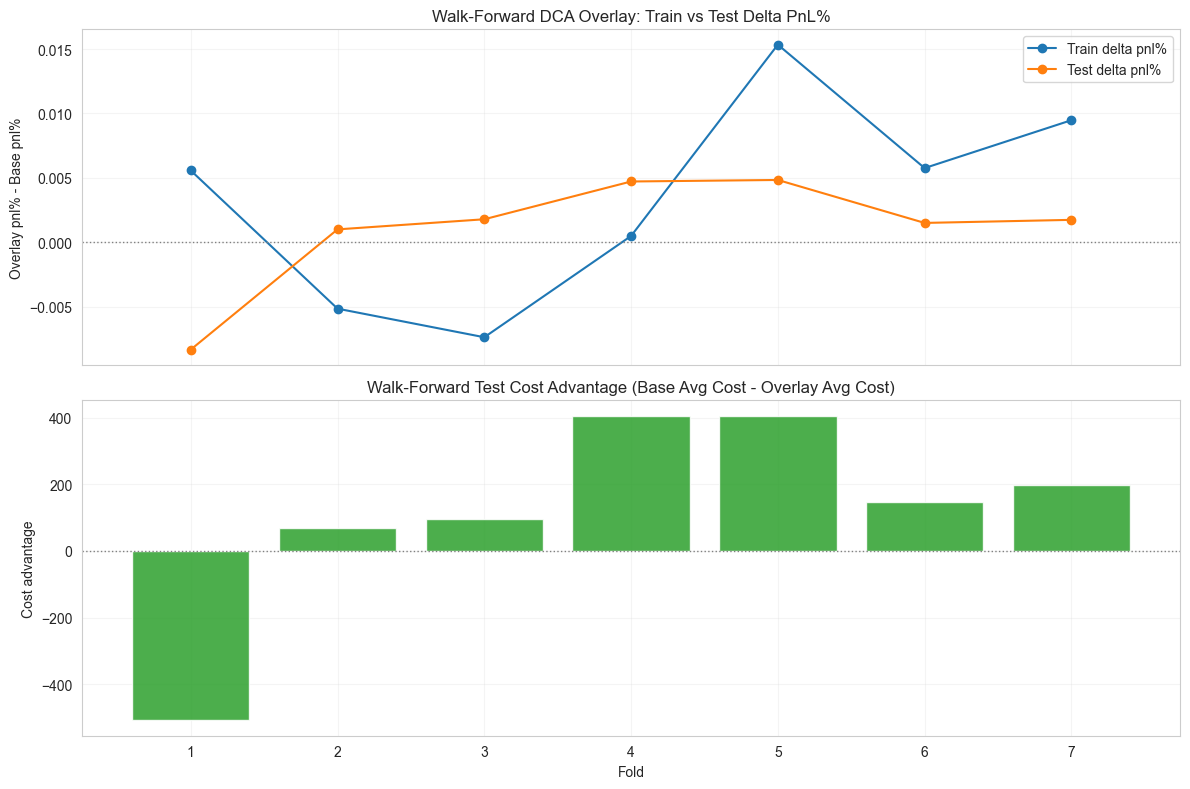

In [14]:
# 4) Regime-wise relationship shift, 5) DCA overlay walk-forward validation
if "kg_time_df" not in globals() or kg_time_df.empty:
    raise RuntimeError("kg_time_df is not available. Run cell 8 first.")

base_daily = (
    kg_time_df[["date", "btc_return", "btc_price", "total_volume", "total_trade_count", "n_markets"]]
    .dropna(subset=["date", "btc_return"] )
    .sort_values("date")
    .reset_index(drop=True)
)

regime_df = base_daily.copy()

def btc_regime_bucket(ret: float) -> str:
    if ret <= -0.01:
        return "Bear (<= -1%)"
    if ret >= 0.01:
        return "Bull (>= +1%)"
    return "Neutral (-1%~+1%)"

regime_df["regime"] = regime_df["btc_return"].apply(btc_regime_bucket)
activity_cols = ["total_volume", "total_trade_count", "n_markets"]

regime_rows = []
for regime, sub in regime_df.groupby("regime"):
    for feat in activity_cols:
        valid = sub[[feat, "btc_return"]].dropna()
        regime_rows.append({
            "regime": regime,
            "feature": feat,
            "corr_same_day": float(valid[feat].corr(valid["btc_return"])) if len(valid) >= 30 else np.nan,
            "n_obs": len(valid),
        })

regime_relation_df = pd.DataFrame(regime_rows)
display(regime_relation_df)

pivot_regime = regime_relation_df.pivot(index="feature", columns="regime", values="corr_same_day")
plt.figure(figsize=(9, 4.5))
sns.heatmap(pivot_regime.fillna(0.0), annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Regime-wise Polymarket -> BTC Relationship (same-day corr)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "raw_kg_regime_activity_btc_corr.png", dpi=150, bbox_inches="tight")
plt.show()

dca_df = base_daily.dropna(subset=["btc_price"]).copy().sort_values("date").reset_index(drop=True)
if len(dca_df) < 450:
    raise RuntimeError("Not enough rows for walk-forward DCA (need at least 450 rows).")

for c in ["total_trade_count", "total_volume", "n_markets"]:
    rolling_mean = dca_df[c].rolling(90, min_periods=20).mean()
    rolling_std = dca_df[c].rolling(90, min_periods=20).std().replace(0, np.nan)
    dca_df[f"z_{c}"] = ((dca_df[c] - rolling_mean) / rolling_std).fillna(0.0)

dca_df["activity_pressure"] = (
    dca_df["z_total_trade_count"] * 0.45
    + dca_df["z_total_volume"] * 0.35
    + dca_df["z_n_markets"] * 0.20
)

def simulate_dca_segment(seg: pd.DataFrame, dip_coef: float, pressure_coef: float, pressure_thr: float, lower: float = 0.75, upper: float = 2.50) -> dict:
    sim = seg[["date", "btc_price", "btc_return", "activity_pressure"]].copy()
    sim["dip_flag"] = (sim["btc_return"] <= -0.01).astype(float)
    sim["overlay_multiplier"] = 1.0 + dip_coef * sim["dip_flag"] + pressure_coef * (sim["activity_pressure"] - pressure_thr).clip(lower=0)
    sim["overlay_multiplier"] = sim["overlay_multiplier"].clip(lower=lower, upper=upper)

    sim["units_base"] = 1.0
    sim["units_overlay"] = sim["units_base"] * sim["overlay_multiplier"]
    sim["invest_base"] = sim["units_base"] * sim["btc_price"]
    sim["invest_overlay"] = sim["units_overlay"] * sim["btc_price"]

    base_units = float(sim["units_base"].sum())
    over_units = float(sim["units_overlay"].sum())
    base_invest = float(sim["invest_base"].sum())
    over_invest = float(sim["invest_overlay"].sum())
    last_price = float(sim["btc_price"].iloc[-1])

    base_value = base_units * last_price
    over_value = over_units * last_price

    return {
        "base_invest": base_invest,
        "overlay_invest": over_invest,
        "base_value": base_value,
        "overlay_value": over_value,
        "base_pnl_pct": (base_value / base_invest - 1.0) if base_invest > 0 else np.nan,
        "overlay_pnl_pct": (over_value / over_invest - 1.0) if over_invest > 0 else np.nan,
        "base_avg_cost": (base_invest / base_units) if base_units > 0 else np.nan,
        "overlay_avg_cost": (over_invest / over_units) if over_units > 0 else np.nan,
        "signal_rate": float((sim["overlay_multiplier"] > 1.0).mean()),
        "mean_multiplier": float(sim["overlay_multiplier"].mean()),
    }

train_days = 365
test_days = 90
step_days = 90

param_grid = []
for dip_coef in [0.30, 0.60, 0.90]:
    for pressure_coef in [0.20, 0.40, 0.60]:
        for pressure_thr in [0.00, 0.50, 1.00]:
            param_grid.append((dip_coef, pressure_coef, pressure_thr))

fold_rows = []
start = 0
fold_id = 1
while start + train_days + test_days <= len(dca_df):
    train_seg = dca_df.iloc[start:start + train_days].copy()
    test_seg = dca_df.iloc[start + train_days:start + train_days + test_days].copy()

    best_params = None
    best_train_score = -np.inf

    for dip_coef, pressure_coef, pressure_thr in param_grid:
        met = simulate_dca_segment(train_seg, dip_coef, pressure_coef, pressure_thr)
        train_score = met["overlay_pnl_pct"] - met["base_pnl_pct"]
        if pd.notna(train_score) and train_score > best_train_score:
            best_train_score = train_score
            best_params = (dip_coef, pressure_coef, pressure_thr)

    if best_params is None:
        start += step_days
        fold_id += 1
        continue

    train_met = simulate_dca_segment(train_seg, *best_params)
    test_met = simulate_dca_segment(test_seg, *best_params)

    fold_rows.append({
        "fold": fold_id,
        "train_start": train_seg["date"].iloc[0],
        "train_end": train_seg["date"].iloc[-1],
        "test_start": test_seg["date"].iloc[0],
        "test_end": test_seg["date"].iloc[-1],
        "dip_coef": best_params[0],
        "pressure_coef": best_params[1],
        "pressure_thr": best_params[2],
        "train_delta_pnl_pct": train_met["overlay_pnl_pct"] - train_met["base_pnl_pct"],
        "test_delta_pnl_pct": test_met["overlay_pnl_pct"] - test_met["base_pnl_pct"],
        "test_base_pnl_pct": test_met["base_pnl_pct"],
        "test_overlay_pnl_pct": test_met["overlay_pnl_pct"],
        "test_cost_advantage": test_met["base_avg_cost"] - test_met["overlay_avg_cost"],
        "test_signal_rate": test_met["signal_rate"],
        "test_mean_multiplier": test_met["mean_multiplier"],
    })

    start += step_days
    fold_id += 1

wf_fold_results = pd.DataFrame(fold_rows)
if wf_fold_results.empty:
    raise RuntimeError("Walk-forward folds were not generated. Check data length or split setup.")

display(wf_fold_results)

wf_summary = pd.DataFrame([{
    "n_folds": int(len(wf_fold_results)),
    "mean_train_delta_pnl_pct": float(wf_fold_results["train_delta_pnl_pct"].mean()),
    "mean_test_delta_pnl_pct": float(wf_fold_results["test_delta_pnl_pct"].mean()),
    "median_test_delta_pnl_pct": float(wf_fold_results["test_delta_pnl_pct"].median()),
    "positive_test_folds": int((wf_fold_results["test_delta_pnl_pct"] > 0).sum()),
    "positive_test_ratio": float((wf_fold_results["test_delta_pnl_pct"] > 0).mean()),
    "mean_test_cost_advantage": float(wf_fold_results["test_cost_advantage"].mean()),
    "overfit_gap_train_minus_test": float(wf_fold_results["train_delta_pnl_pct"].mean() - wf_fold_results["test_delta_pnl_pct"].mean()),
}])
display(wf_summary)

best_all_params = None
best_all_score = -np.inf
for dip_coef, pressure_coef, pressure_thr in param_grid:
    all_met = simulate_dca_segment(dca_df, dip_coef, pressure_coef, pressure_thr)
    score = all_met["overlay_pnl_pct"] - all_met["base_pnl_pct"]
    if pd.notna(score) and score > best_all_score:
        best_all_score = score
        best_all_params = (dip_coef, pressure_coef, pressure_thr)

insample_cmp = pd.DataFrame([{
    "best_all_dip_coef": best_all_params[0],
    "best_all_pressure_coef": best_all_params[1],
    "best_all_pressure_thr": best_all_params[2],
    "best_all_delta_pnl_pct": best_all_score,
    "wf_mean_test_delta_pnl_pct": float(wf_fold_results["test_delta_pnl_pct"].mean()),
    "insample_minus_wf_test": float(best_all_score - wf_fold_results["test_delta_pnl_pct"].mean()),
}])
display(insample_cmp)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(wf_fold_results["fold"], wf_fold_results["train_delta_pnl_pct"], marker="o", label="Train delta pnl%", color="#1f77b4")
axes[0].plot(wf_fold_results["fold"], wf_fold_results["test_delta_pnl_pct"], marker="o", label="Test delta pnl%", color="#ff7f0e")
axes[0].axhline(0, color="gray", linestyle=":", linewidth=1)
axes[0].set_title("Walk-Forward DCA Overlay: Train vs Test Delta PnL%")
axes[0].set_ylabel("Overlay pnl% - Base pnl%")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].bar(wf_fold_results["fold"], wf_fold_results["test_cost_advantage"], color="#2ca02c", alpha=0.85)
axes[1].axhline(0, color="gray", linestyle=":", linewidth=1)
axes[1].set_title("Walk-Forward Test Cost Advantage (Base Avg Cost - Overlay Avg Cost)")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Cost advantage")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "raw_kg_dca_overlay_walkforward.png", dpi=150, bbox_inches="tight")
plt.show()



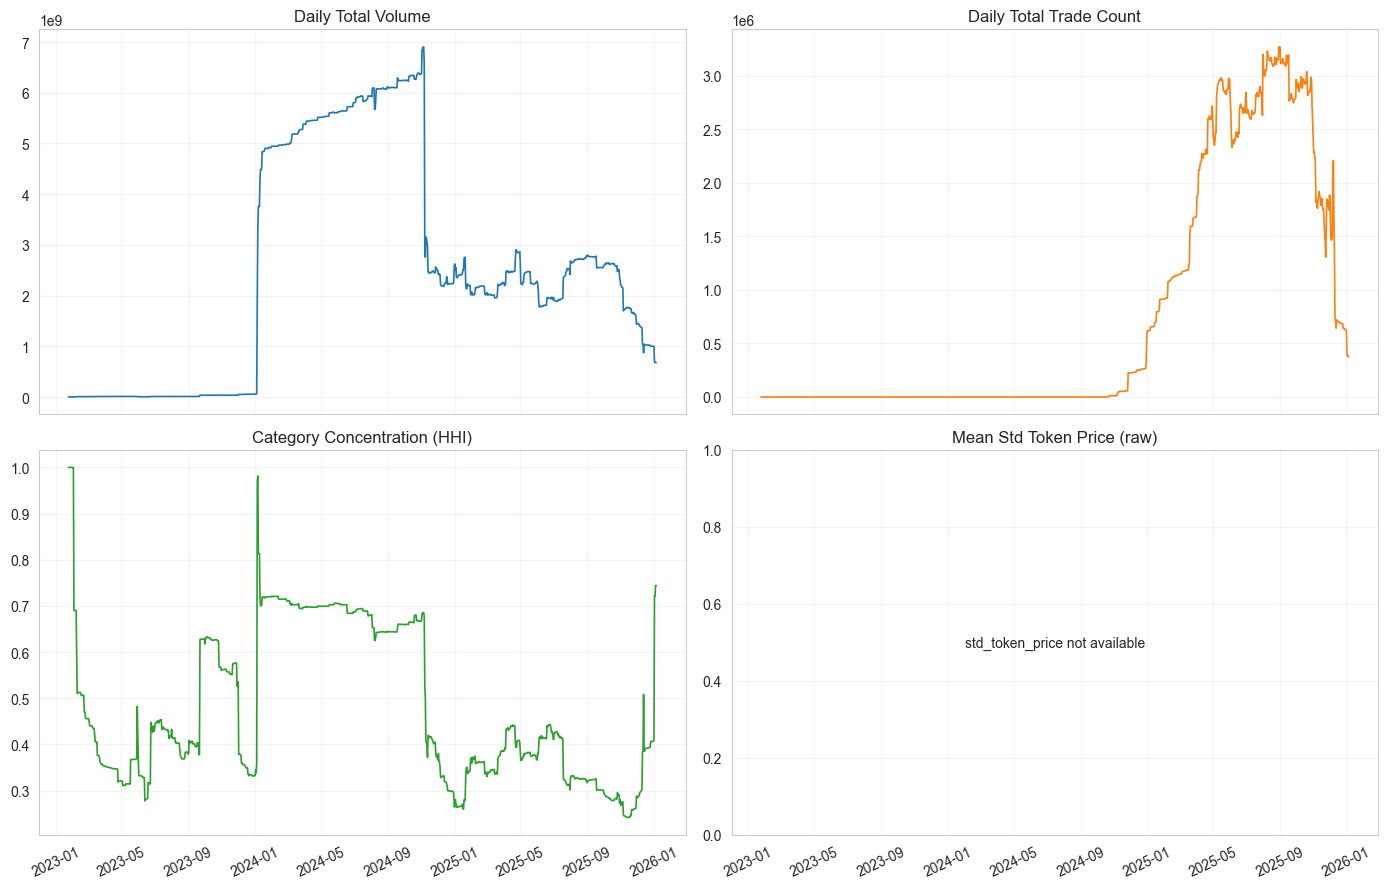

,date,total_volume,total_trade_count,mean_trade_rows,mean_trade_size_sum,mean_trade_price_std,n_markets,n_categories,category_hhi
0,2023-01-24,768347.26,0.0,0.0,0.0,0.0,1,1,1.0
1,2023-01-25,1106601.54,0.0,0.0,0.0,0.0,2,1,1.0
2,2023-01-26,1106601.54,0.0,0.0,0.0,0.0,2,1,1.0
3,2023-01-27,1145710.25,0.0,0.0,0.0,0.0,5,1,1.0
4,2023-01-28,1145710.25,0.0,0.0,0.0,0.0,5,1,1.0


In [15]:
agg_spec = {
    "total_volume": ("volume", "sum"),
    "total_trade_count": ("trade_count", "sum"),
    "mean_trade_rows": ("trade_rows", "mean"),
    "mean_trade_size_sum": ("trade_size_sum", "mean"),
    "mean_trade_price_std": ("trade_price_std", "mean"),
    "n_markets": ("market_id", "nunique"),
    "n_categories": ("category", "nunique"),
}

if "active_trade_ratio" in graph_df.columns:
    agg_spec["mean_active_trade_ratio"] = ("active_trade_ratio", "mean")
if "std_token_price" in graph_df.columns:
    agg_spec["mean_std_token_price"] = ("std_token_price", "mean")

daily_raw = (
    graph_df.groupby("created_at")
    .agg(**agg_spec)
    .reset_index()
    .rename(columns={"created_at": "date"})
    .sort_values("date")
)

cat_share = graph_df.groupby(["created_at", "category"], as_index=False)["volume"].sum()
cat_share["vol_share"] = cat_share.groupby("created_at")["volume"].transform(lambda x: x / x.sum() if x.sum() > 0 else 0.0)
hhi = cat_share.groupby("created_at", as_index=False)["vol_share"].apply(lambda x: float((x ** 2).sum())).rename(columns={"created_at": "date", "vol_share": "category_hhi"})
daily_raw = daily_raw.merge(hhi, on="date", how="left")

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()

axes[0].plot(daily_raw["date"], daily_raw["total_volume"], color="#1f77b4", lw=1.2)
axes[0].set_title("Daily Total Volume")
axes[0].grid(alpha=0.2)

axes[1].plot(daily_raw["date"], daily_raw["total_trade_count"], color="#ff7f0e", lw=1.2)
axes[1].set_title("Daily Total Trade Count")
axes[1].grid(alpha=0.2)

axes[2].plot(daily_raw["date"], daily_raw["category_hhi"], color="#2ca02c", lw=1.2)
axes[2].set_title("Category Concentration (HHI)")
axes[2].grid(alpha=0.2)

if "mean_std_token_price" in daily_raw.columns:
    axes[3].plot(daily_raw["date"], daily_raw["mean_std_token_price"], color="#d62728", lw=1.2)
    axes[3].set_title("Mean Std Token Price (raw)")
else:
    axes[3].text(0.5, 0.5, "std_token_price not available", ha="center", va="center", transform=axes[3].transAxes)
    axes[3].set_title("Mean Std Token Price (raw)")
axes[3].grid(alpha=0.2)

for ax in axes:
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "raw_kg_daily_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

daily_raw.head(5)

,feature,corr_with_btc_ret_1d
6,n_markets,-0.049569
5,category_hhi,0.046280
7,n_categories,-0.035524
2,mean_trade_rows,-0.032565
1,total_trade_count,-0.030370
3,mean_trade_size_sum,-0.008005
4,mean_trade_price_std,0.001178
0,total_volume,0.000700


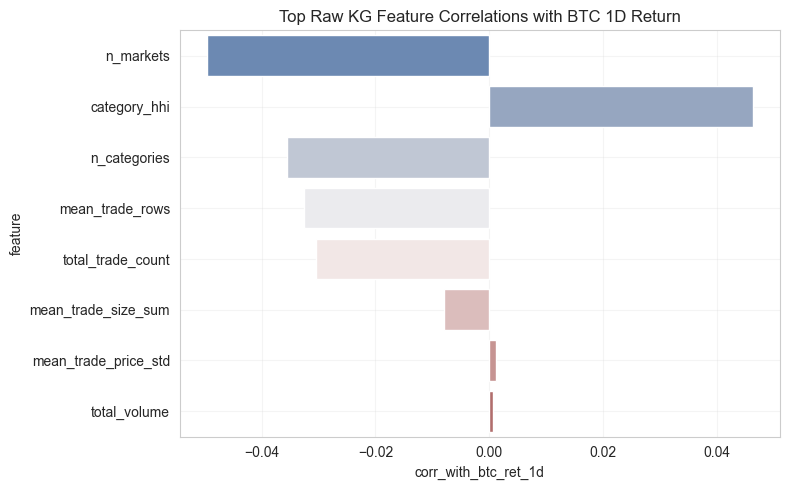

In [16]:
coinmetrics_path = PROJECT_ROOT / "data" / "Coin Metrics" / "coinmetrics_btc.csv"
if coinmetrics_path.exists():
    btc = pd.read_csv(coinmetrics_path)
    if "time" in btc.columns and "PriceUSD" in btc.columns:
        btc = btc[["time", "PriceUSD"]].copy()
        btc["date"] = pd.to_datetime(btc["time"]).dt.normalize()
        btc = btc.drop(columns=["time"]).dropna().sort_values("date")

        merged = daily_raw.merge(btc, on="date", how="inner").sort_values("date")
        merged["btc_ret_1d"] = np.log(merged["PriceUSD"]/merged["PriceUSD"].shift(1))

        feature_cols = [
            "total_volume", "total_trade_count", "mean_trade_rows", "mean_trade_size_sum",
            "mean_trade_price_std", "category_hhi", "n_markets", "n_categories",
            "mean_active_trade_ratio", "mean_std_token_price",
        ]
        feature_cols = [c for c in feature_cols if c in merged.columns]

        corr_rows = []
        for col in feature_cols:
            valid = merged[[col, "btc_ret_1d"]].dropna()
            if len(valid) > 30:
                corr_rows.append({
                    "feature": col,
                    "corr_with_btc_ret_1d": float(valid[col].corr(valid["btc_ret_1d"])),
                })

        corr_df = pd.DataFrame(corr_rows).sort_values("corr_with_btc_ret_1d", key=lambda s: s.abs(), ascending=False)
        display(corr_df)

        if not corr_df.empty:
            top10 = corr_df.head(10).copy()
            plt.figure(figsize=(8, 5))
            sns.barplot(
                data=top10,
                x="corr_with_btc_ret_1d",
                y="feature",
                hue="feature",
                dodge=False,
                palette="vlag",
                legend=False,
            )
            plt.title("Top Raw KG Feature Correlations with BTC 1D Return")
            plt.grid(alpha=0.2)
            plt.tight_layout()
            plt.savefig(PLOTS_DIR / "raw_kg_btc_feature_corr.png", dpi=150, bbox_inches="tight")
            plt.show()
    else:
        print("coinmetrics_btc.csv missing required columns: time, PriceUSD")
else:
    print("coinmetrics_btc.csv not found; skipped BTC linkage analysis")

## Natural Research Direction (Pure Raw Graph)

- Timestamp cleaning is applied only to mandatory fields (`markets.created_at/end_date`, `trades.timestamp`, `odds.timestamp`).
- The graph model uses raw entities and links (`time`, `market`, `category`, `event`, `token`, `outcome`) without composite engagement index.
- Interpret BTC linkage as **raw structural association** (not a standalone predictor), and focus on regime/context signals such as concentration, activity, and market-structure shifts.
- For next iteration: extend temporal graph metrics (centrality drift, community persistence, churn) and evaluate stability across sub-periods.

## Empirical Findings (Raw KG)

- Mandatory timestamp corrections were applied to `markets.created_at/end_date`, `trades.timestamp`, and `odds.timestamp` before analysis.
- Pure raw graph was constructed at large scale (time-market-category-event-token-outcome) without any composite index.
- Daily raw graph features showed only weak linear association with BTC 1-day returns (absolute correlations were small).
- This supports using raw KG features mainly as context/regime descriptors rather than standalone short-horizon predictors.
- Next practical step is lagged/regime-split testing on the same raw features and graph-topology drift metrics.

## Lag & Period-Split Extension (Raw KG)

This section extends the raw-KG analysis with:
- Lead/lag checks at 7, 14, 30 days
- Period split comparison (2023-2024 vs 2025)

,feature,horizon_days,corr_feature_leads_btc,corr_btc_leads_feature,lead_minus_lag
0,total_volume,7,0.011770,0.002841,0.008929
1,total_volume,14,0.019396,-0.005720,0.025116
2,total_volume,30,0.014232,-0.009179,0.023411
3,total_trade_count,7,-0.035915,-0.027143,-0.008772
4,total_trade_count,14,-0.038062,-0.030519,-0.007543
5,total_trade_count,30,-0.042982,-0.018239,-0.024744
6,mean_trade_rows,7,-0.042446,-0.031875,-0.010570
7,mean_trade_rows,14,-0.051383,-0.038490,-0.012893
8,mean_trade_rows,30,-0.041751,-0.012375,-0.029376
9,mean_trade_size_sum,7,-0.008255,0.015026,-0.023281


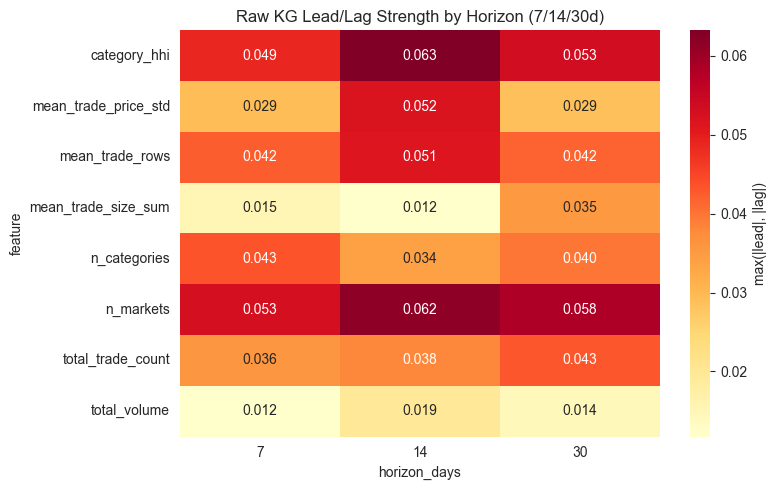

Top |feature leads BTC| pairs:


,feature,horizon_days,corr_feature_leads_btc,corr_btc_leads_feature,lead_minus_lag
16,category_hhi,14,0.063237,0.026748,0.036489
17,category_hhi,30,0.053253,0.002652,0.050601
7,mean_trade_rows,14,-0.051383,-0.038490,-0.012893
15,category_hhi,7,0.048591,0.040649,0.007942
18,n_markets,7,-0.044867,-0.052822,0.007955
20,n_markets,30,-0.043044,-0.058271,0.015226
5,total_trade_count,30,-0.042982,-0.018239,-0.024744
6,mean_trade_rows,7,-0.042446,-0.031875,-0.010570
8,mean_trade_rows,30,-0.041751,-0.012375,-0.029376
19,n_markets,14,-0.041750,-0.061618,0.019868


Top |BTC leads feature| pairs:


,feature,horizon_days,corr_feature_leads_btc,corr_btc_leads_feature,lead_minus_lag
19,n_markets,14,-0.041750,-0.061618,0.019868
20,n_markets,30,-0.043044,-0.058271,0.015226
18,n_markets,7,-0.044867,-0.052822,0.007955
13,mean_trade_price_std,14,-0.031252,-0.051806,0.020555
21,n_categories,7,-0.031126,-0.043333,0.012207
15,category_hhi,7,0.048591,0.040649,0.007942
23,n_categories,30,-0.014653,-0.039794,0.025141
7,mean_trade_rows,14,-0.051383,-0.038490,-0.012893
22,n_categories,14,-0.009810,-0.034052,0.024242
6,mean_trade_rows,7,-0.042446,-0.031875,-0.010570


In [17]:
# Ensure base merged frame exists
if "merged" not in globals():
    raise RuntimeError("`merged` is not available. Run the BTC linkage cell first.")

analysis_df = merged.copy().sort_values("date").reset_index(drop=True)
analysis_df["btc_ret_1d"] = np.log(analysis_df["PriceUSD"] / analysis_df["PriceUSD"].shift(1))
analysis_df = analysis_df.replace([np.inf, -np.inf], np.nan)

feature_cols_lag = [
    "total_volume", "total_trade_count", "mean_trade_rows", "mean_trade_size_sum",
    "mean_trade_price_std", "category_hhi", "n_markets", "n_categories",
    "mean_active_trade_ratio", "mean_std_token_price",
]
feature_cols_lag = [c for c in feature_cols_lag if c in analysis_df.columns]

if len(feature_cols_lag) == 0:
    raise RuntimeError("No valid raw features are available for lag analysis.")

horizons = [7, 14, 30]
lag_rows = []

for feat in feature_cols_lag:
    for h in horizons:
        lead = analysis_df[[feat, "btc_ret_1d"]].copy()
        lead["target"] = lead["btc_ret_1d"].shift(-h)
        lead = lead[[feat, "target"]].dropna()
        lead_corr = float(lead[feat].corr(lead["target"])) if len(lead) > 30 else np.nan

        lag = analysis_df[[feat, "btc_ret_1d"]].copy()
        lag["target"] = lag["btc_ret_1d"].shift(h)
        lag = lag[[feat, "target"]].dropna()
        lag_corr = float(lag[feat].corr(lag["target"])) if len(lag) > 30 else np.nan

        lag_rows.append({
            "feature": feat,
            "horizon_days": h,
            "corr_feature_leads_btc": lead_corr,
            "corr_btc_leads_feature": lag_corr,
            "lead_minus_lag": lead_corr - lag_corr if pd.notna(lead_corr) and pd.notna(lag_corr) else np.nan,
        })

lag_df = pd.DataFrame(lag_rows)
display(lag_df.head(12))

plot_df = lag_df.copy()
plot_df["dominant_abs_corr"] = plot_df[["corr_feature_leads_btc", "corr_btc_leads_feature"]].abs().max(axis=1)
pivot_abs = plot_df.pivot(index="feature", columns="horizon_days", values="dominant_abs_corr")

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_abs, annot=True, fmt=".3f", cmap="YlOrRd", cbar_kws={"label": "max(|lead|, |lag|)"})
plt.title("Raw KG Lead/Lag Strength by Horizon (7/14/30d)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "raw_kg_lead_lag_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

top_lead = lag_df.sort_values("corr_feature_leads_btc", key=lambda s: s.abs(), ascending=False).head(10)
top_lag = lag_df.sort_values("corr_btc_leads_feature", key=lambda s: s.abs(), ascending=False).head(10)

print("Top |feature leads BTC| pairs:")
display(top_lead[["feature", "horizon_days", "corr_feature_leads_btc", "corr_btc_leads_feature", "lead_minus_lag"]])

print("Top |BTC leads feature| pairs:")
display(top_lag[["feature", "horizon_days", "corr_feature_leads_btc", "corr_btc_leads_feature", "lead_minus_lag"]])

c:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-0

,period,feature,corr_with_btc_ret_1d,n_obs
0,2023-2024,total_volume,-0.005929,695
1,2023-2024,total_trade_count,-0.006355,695
2,2023-2024,mean_trade_rows,NaN,695
3,2023-2024,mean_trade_size_sum,NaN,695
4,2023-2024,mean_trade_price_std,NaN,695
5,2023-2024,category_hhi,0.016282,695
6,2023-2024,n_markets,-0.014196,695
7,2023-2024,n_categories,-0.004914,695
8,2025,total_volume,0.049604,365
9,2025,total_trade_count,0.038791,365


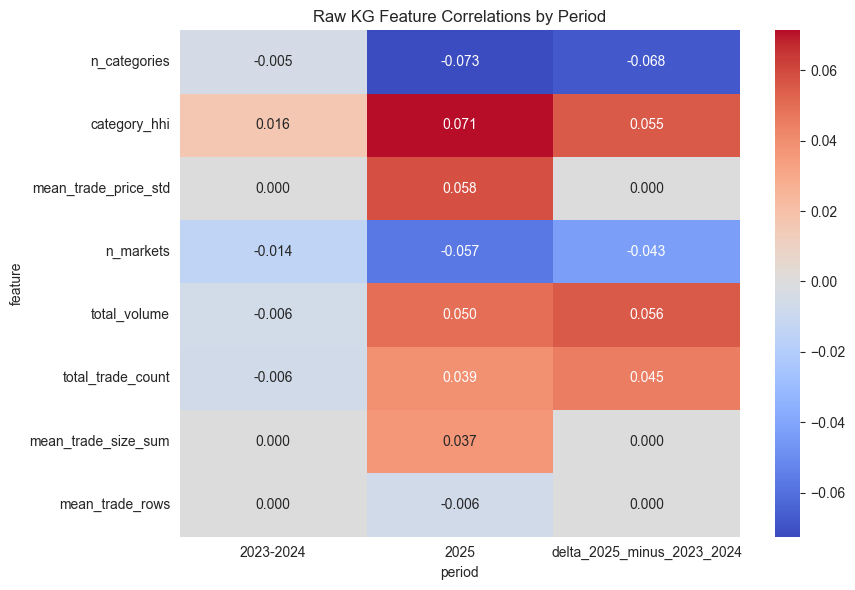

Period split summary (top abs by 2025):


period,feature,2023-2024,2025,delta_2025_minus_2023_2024
0,n_categories,-0.004914,-0.072530,-0.067616
1,category_hhi,0.016282,0.071365,0.055083
2,mean_trade_price_std,NaN,0.058380,NaN
3,n_markets,-0.014196,-0.057337,-0.043141
4,total_volume,-0.005929,0.049604,0.055533
5,total_trade_count,-0.006355,0.038791,0.045146
6,mean_trade_size_sum,NaN,0.036879,NaN
7,mean_trade_rows,NaN,-0.006382,NaN


In [18]:
# Period split: 2023-2024 vs 2025
periods = {
    "2023-2024": (pd.Timestamp("2023-01-01"), pd.Timestamp("2024-12-31")),
    "2025": (pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31")),
}

split_rows = []
for period_name, (start_dt, end_dt) in periods.items():
    sub = analysis_df[(analysis_df["date"] >= start_dt) & (analysis_df["date"] <= end_dt)].copy()
    if len(sub) < 60:
        continue

    for feat in feature_cols_lag:
        valid = sub[[feat, "btc_ret_1d"]].dropna()
        if len(valid) > 30:
            split_rows.append({
                "period": period_name,
                "feature": feat,
                "corr_with_btc_ret_1d": float(valid[feat].corr(valid["btc_ret_1d"])),
                "n_obs": len(valid),
            })

split_df = pd.DataFrame(split_rows)
display(split_df.head(12))

if not split_df.empty:
    pivot_split = split_df.pivot(index="feature", columns="period", values="corr_with_btc_ret_1d")
    if set(["2023-2024", "2025"]).issubset(pivot_split.columns):
        pivot_split["delta_2025_minus_2023_2024"] = pivot_split["2025"] - pivot_split["2023-2024"]
    pivot_split = pivot_split.sort_values("2025", key=lambda s: s.abs(), ascending=False) if "2025" in pivot_split.columns else pivot_split

    plt.figure(figsize=(9, 6))
    sns.heatmap(pivot_split.fillna(0), annot=True, fmt=".3f", cmap="coolwarm", center=0)
    plt.title("Raw KG Feature Correlations by Period")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "raw_kg_period_split_corr.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("Period split summary (top abs by 2025):")
    display(pivot_split.reset_index())
else:
    print("No valid period-split rows generated.")

## Centrality Drift as Structural Narrative-Change Signal (Top 5 Events)

Core objective: define **centrality drift as a structural narrative-change signal** in the market and link it to BTC reactions.

Validate the following five questions under one consistent framework:

1. **Does BTC move when a specific event suddenly becomes central?** (daily/weekly return)
2. **Does a surge in event centrality lead BTC volatility?**
3. **On high centrality-drift days, does BTC rise or fall on average?** (directly connected to DCA overlay)
4. **Which category-level centrality drift triggers the strongest BTC sensitivity?**
5. **Can centrality drift anticipate regime transitions?**

The method uses `NetworkX` to compute daily event centrality (`degree`, `betweenness`, `eigenvector`) and defines event-level centrality differences as `centrality_drift`, then links them with BTC return and volatility.

Top slug count (impact top 15): 15
Eligible slugs with active_days >= 10: 8
Detected jump events among eligible top slugs (|robust z| >= 4.0): 128


,event_slug,n_jumps,max_abs_jump_z,max_abs_diff,mean_centrality,latest_centrality,active_days
0,fed-decision-in-december,32,1.919980e+06,0.162221,0.199904,0.707107,321
1,fed-decision-in-july,32,2.843840e+02,0.180017,0.203205,0.000000,321
2,fed-decision-in-october,32,1.203551e+02,0.162221,0.224549,0.000000,321
3,fed-decision-in-september,32,1.160543e+02,0.162221,0.228975,0.000000,321
4,fed-decision-in-may-2025,0,0.000000e+00,0.276635,0.105230,0.000000,321
5,fed-decision-in-june,0,0.000000e+00,0.199599,0.156391,0.000000,321
6,people-power-party-ppp-presidential-candidate,0,0.000000e+00,0.135823,0.093939,0.000000,321
7,will-trump-lower-tariffs-on-china-in-april,0,0.000000e+00,0.063402,0.065365,0.000000,321


Top jump events:


,date,event_slug,eig_centrality,centrality_diff,abs_diff,diff_robust_z
73,2025-04-07,fed-decision-in-december,1.957872e-249,-0.162221,0.162221,-1.919980e+06
1,2025-01-25,fed-decision-in-december,3.162278e-01,-0.017106,0.017106,-2.024538e+05
202,2025-08-14,fed-decision-in-december,1.153374e-01,0.015942,0.015942,1.886882e+05
208,2025-08-20,fed-decision-in-december,1.936123e-01,0.015883,0.015883,1.879890e+05
209,2025-08-21,fed-decision-in-december,2.090094e-01,0.015397,0.015397,1.822334e+05
2,2025-01-26,fed-decision-in-december,3.015113e-01,-0.014716,0.014716,-1.741770e+05
204,2025-08-16,fed-decision-in-december,1.428254e-01,0.014710,0.014710,1.741028e+05
294,2025-11-14,fed-decision-in-december,5.787857e-01,0.014265,0.014265,1.688304e+05
210,2025-08-22,fed-decision-in-december,2.230199e-01,0.014011,0.014011,1.658221e+05
201,2025-08-13,fed-decision-in-december,9.939488e-02,0.013946,0.013946,1.650631e+05


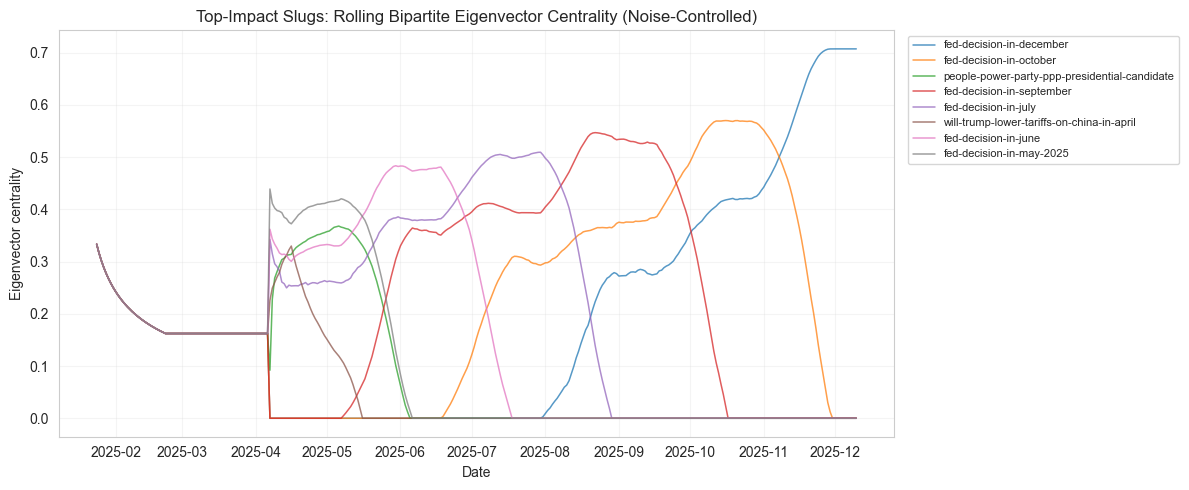

In [19]:
# Top-15 Event Slugs by Volume-Intensity Impact: rolling bipartite centrality jump detection (noise-controlled)
if "kg_market_df" not in globals() or kg_market_df.empty:
    raise RuntimeError("kg_market_df is not available. Run Cell 8 first.")
if "slug_impact_df" not in globals() or slug_impact_df is None or slug_impact_df.empty:
    raise RuntimeError("slug_impact_df is not available. Run Cell 8 first.")

window_days = 30
min_active_days_target = 10
z_threshold = 4.0

top15_slugs = (
    slug_impact_df.sort_values("impact_score", ascending=False)["event_slug"]
    .astype(str).str.strip()
    .head(15).tolist()
)
top15_slugs = [s for s in top15_slugs if s and s.lower() != "unknown"]
print(f"Top slug count (impact top 15): {len(top15_slugs)}")

work = kg_market_df.copy()
work["event_slug"] = work["event_slug"].astype(str).str.strip()
work["date"] = pd.to_datetime(work["date"]).dt.normalize()
work = work[work["event_slug"].isin(top15_slugs)].copy()

if work.empty:
    raise RuntimeError("No rows found for top-15 slugs in kg_market_df.")

daily_slug = (
    work.groupby(["date", "event_slug"], as_index=False)
    .agg(
        volume=("volume", "sum"),
        trade_count=("trade_count", "sum"),
    )
    .sort_values(["date", "event_slug"] )
)

daily_slug["w_edge"] = np.log1p(daily_slug["volume"].clip(lower=0.0))

active_days_by_slug = daily_slug.groupby("event_slug")["date"].nunique()
candidate_thresholds = [min_active_days_target, 7, 5, 3, 1]
effective_min_active_days = None
eligible_slugs = []

for th in candidate_thresholds:
    cand = active_days_by_slug[active_days_by_slug >= th].index.tolist()
    cand = [s for s in top15_slugs if s in set(cand)]
    if len(cand) > 0:
        eligible_slugs = cand
        effective_min_active_days = th
        break

if len(eligible_slugs) == 0:
    raise RuntimeError("No eligible slug found even after fallback thresholds.")

print(f"Eligible slugs with active_days >= {effective_min_active_days}: {len(eligible_slugs)}")
if effective_min_active_days < min_active_days_target:
    print(f"Note: sparse data prevented >= {min_active_days_target} days filter; fallback to >= {effective_min_active_days} days.")

daily_slug = daily_slug[daily_slug["event_slug"].isin(eligible_slugs)].copy()

all_dates = sorted(daily_slug["date"].unique())
centrality_rows = []

for end_date in all_dates:
    start_date = end_date - pd.Timedelta(days=window_days - 1)
    w = daily_slug[(daily_slug["date"] >= start_date) & (daily_slug["date"] <= end_date)]
    if w.empty:
        continue

    B = nx.Graph()

    for s in eligible_slugs:
        B.add_node(f"slug::{s}", bipartite="slug", event_slug=s)

    for _, r in w.iterrows():
        d = pd.to_datetime(r["date"]).strftime("%Y-%m-%d")
        day_node = f"day::{d}"
        slug_node = f"slug::{r['event_slug']}"
        if day_node not in B:
            B.add_node(day_node, bipartite="day", day=d)
        B.add_edge(slug_node, day_node, weight=float(r["w_edge"]))

    if B.number_of_edges() == 0:
        eig_slug = {s: 0.0 for s in eligible_slugs}
    else:
        try:
            eig_all = nx.eigenvector_centrality(B, max_iter=4000, tol=1e-08, weight="weight")
            eig_slug = {s: float(eig_all.get(f"slug::{s}", 0.0)) for s in eligible_slugs}
        except Exception:
            deg = nx.degree_centrality(B)
            eig_slug = {s: float(deg.get(f"slug::{s}", 0.0)) for s in eligible_slugs}

    for s in eligible_slugs:
        centrality_rows.append({
            "date": end_date,
            "event_slug": s,
            "eig_centrality": float(eig_slug.get(s, 0.0)),
        })

cent_df = pd.DataFrame(centrality_rows).sort_values(["event_slug", "date"]).reset_index(drop=True)
cent_df["centrality_diff"] = cent_df.groupby("event_slug")["eig_centrality"].diff()
cent_df["abs_diff"] = cent_df["centrality_diff"].abs()

def robust_zscore(x: pd.Series) -> pd.Series:
    valid = x.dropna()
    if len(valid) < 8:
        return pd.Series(np.zeros(len(x)), index=x.index)
    med = valid.median()
    mad = (valid - med).abs().median()
    scale = 1.4826 * mad
    if pd.isna(scale) or scale <= 1e-12:
        return pd.Series(np.zeros(len(x)), index=x.index)
    out = (x - med) / scale
    return out.fillna(0.0)

cent_df["diff_robust_z"] = cent_df.groupby("event_slug")["centrality_diff"].transform(robust_zscore)
cent_df["slug_q90_abs_diff"] = cent_df.groupby("event_slug")["abs_diff"].transform(lambda s: s.quantile(0.90))

cent_df["is_jump"] = (
    cent_df["diff_robust_z"].abs() >= z_threshold
    ) & (
    cent_df["abs_diff"] >= cent_df["slug_q90_abs_diff"]
    )

jump_events = cent_df[cent_df["is_jump"]].copy()
jump_summary = (
    cent_df.groupby("event_slug", as_index=False)
    .agg(
        n_jumps=("is_jump", "sum"),
        max_abs_jump_z=("diff_robust_z", lambda s: float(np.nanmax(np.abs(s.values))) if len(s) > 0 else np.nan),
        max_abs_diff=("abs_diff", "max"),
        mean_centrality=("eig_centrality", "mean"),
        latest_centrality=("eig_centrality", "last"),
        active_days=("date", "nunique"),
    )
    .sort_values(["n_jumps", "max_abs_jump_z", "max_abs_diff"], ascending=[False, False, False])
    .reset_index(drop=True)
)

print(f"Detected jump events among eligible top slugs (|robust z| >= {z_threshold}): {len(jump_events)}")
display(jump_summary)

if not jump_events.empty:
    print("Top jump events:")
    display(
        jump_events[["date", "event_slug", "eig_centrality", "centrality_diff", "abs_diff", "diff_robust_z"]]
        .sort_values(["diff_robust_z", "abs_diff"], key=lambda s: s.abs(), ascending=False)
        .head(30)
    )
else:
    print("No abrupt centrality jump detected under current noise-controlled setting.")

plt.figure(figsize=(12, 5))
for s in eligible_slugs:
    sub = cent_df[cent_df["event_slug"] == s]
    plt.plot(sub["date"], sub["eig_centrality"], linewidth=1.1, alpha=0.75, label=s)
plt.title("Top-Impact Slugs: Rolling Bipartite Eigenvector Centrality (Noise-Controlled)")
plt.xlabel("Date")
plt.ylabel("Eigenvector centrality")
plt.grid(alpha=0.2)
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8)
plt.tight_layout()
plt.show()

## Category-Level Centrality Drift vs BTC Response

Goal: find categories where **centrality drift** has the strongest link to BTC return and BTC volatility.

Approach: compute rolling bipartite category centrality (`category`-`day`), derive daily `centrality_drift`, then rank categories by return/volatility sensitivity.

Top categories by centrality-drift BTC sensitivity:


,category,n_obs,corr_drift_btc_same,corr_drift_btc_fwd1,corr_drift_btc_fwd7,corr_drift_btc_vol_fwd7,jump_day_mean_btc_ret,jump_day_mean_abs_btc_ret,strength_score
0,Tech,1056,-0.061483,0.074460,-0.021304,0.014891,0.002744,0.017675,0.043034
1,Pop-Culture,1056,0.025305,-0.088047,0.023726,-0.021623,0.000135,0.017524,0.039675
2,Sports,1056,-0.013883,0.050387,-0.028471,-0.036845,0.000737,0.016465,0.032397
3,Coronavirus,1056,-0.025823,0.049154,-0.014826,-0.033451,0.001206,0.017050,0.030814
4,Crypto,1056,0.025901,-0.044136,0.012278,0.017193,0.001517,0.017210,0.024877
5,US-Current-Affairs,1056,0.029692,-0.045228,0.016197,0.008282,0.002005,0.015307,0.024850
6,Business,1056,0.030679,-0.050649,0.007313,0.008280,-0.001308,0.016267,0.024230
7,Politics,1056,0.017090,-0.050203,0.017567,0.011944,0.001498,0.016856,0.024201
8,Global-Politics,1056,0.017725,-0.043895,0.014141,0.019054,0.002521,0.016624,0.023704
9,Ukraine & Russia,1056,0.012983,-0.026461,0.020759,0.023373,-0.000511,0.015772,0.020894


Top 5 categories (drift strength):


,category,strength_score,corr_drift_btc_same,corr_drift_btc_fwd1,corr_drift_btc_fwd7,corr_drift_btc_vol_fwd7,jump_day_mean_btc_ret,jump_day_mean_abs_btc_ret,n_obs
0,Tech,0.043034,-0.061483,0.074460,-0.021304,0.014891,0.002744,0.017675,1056
1,Pop-Culture,0.039675,0.025305,-0.088047,0.023726,-0.021623,0.000135,0.017524,1056
2,Sports,0.032397,-0.013883,0.050387,-0.028471,-0.036845,0.000737,0.016465,1056
3,Coronavirus,0.030814,-0.025823,0.049154,-0.014826,-0.033451,0.001206,0.017050,1056
4,Crypto,0.024877,0.025901,-0.044136,0.012278,0.017193,0.001517,0.017210,1056


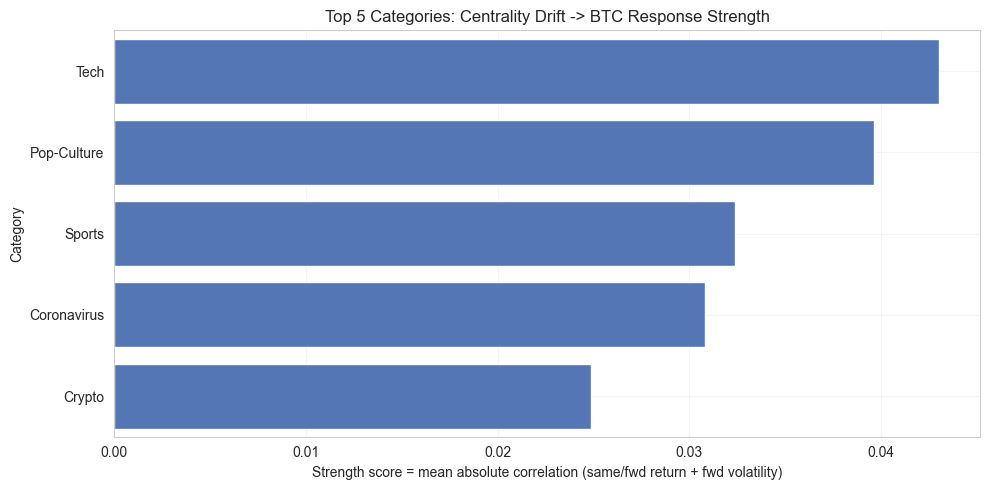

In [20]:
# Category-level centrality drift -> BTC response strength (robust for sparse data)
if "kg_market_df" not in globals() or kg_market_df.empty:
    raise RuntimeError("kg_market_df is not available. Run Cell 8 first.")

window_days = 30
min_obs_per_category = 30

cat_base = kg_market_df.copy()
cat_base["date"] = pd.to_datetime(cat_base["date"]).dt.normalize()
cat_base["category"] = cat_base["category"].astype(str).str.strip()
cat_base = cat_base[(cat_base["category"] != "") & (cat_base["category"].str.lower() != "unknown")].copy()

if cat_base.empty:
    raise RuntimeError("No valid category rows are available for centrality drift analysis.")

cat_day = (
    cat_base.groupby(["date", "category"], as_index=False)
    .agg(
        volume_sum=("volume", "sum"),
        trade_sum=("trade_count", "sum"),
        btc_return=("btc_return", "mean"),
    )
    .sort_values(["date", "category"])
    .reset_index(drop=True)
)

cat_day["edge_weight"] = np.log1p(cat_day["volume_sum"].clip(lower=0.0)) + 0.30 * np.log1p(cat_day["trade_sum"].clip(lower=0.0))

all_dates = sorted(cat_day["date"].unique())
categories = sorted(cat_day["category"].unique())
centrality_rows = []

for end_date in all_dates:
    start_date = end_date - pd.Timedelta(days=window_days - 1)
    w = cat_day[(cat_day["date"] >= start_date) & (cat_day["date"] <= end_date)]
    if w.empty:
        continue

    B = nx.Graph()
    for cat in categories:
        B.add_node(f"cat::{cat}", bipartite="category", category=cat)

    for _, r in w.iterrows():
        day_key = pd.to_datetime(r["date"]).strftime("%Y-%m-%d")
        d_node = f"day::{day_key}"
        c_node = f"cat::{r['category']}"
        if d_node not in B:
            B.add_node(d_node, bipartite="day", day=day_key)
        B.add_edge(c_node, d_node, weight=float(r["edge_weight"]))

    if B.number_of_edges() == 0:
        cent_map = {cat: 0.0 for cat in categories}
    else:
        try:
            eig = nx.eigenvector_centrality(B, max_iter=4000, tol=1e-08, weight="weight")
            cent_map = {cat: float(eig.get(f"cat::{cat}", 0.0)) for cat in categories}
        except Exception:
            deg = nx.degree_centrality(B)
            cent_map = {cat: float(deg.get(f"cat::{cat}", 0.0)) for cat in categories}

    for cat in categories:
        centrality_rows.append({
            "date": end_date,
            "category": cat,
            "cat_centrality": float(cent_map.get(cat, 0.0)),
        })

cat_cent_df = pd.DataFrame(centrality_rows).sort_values(["category", "date"]).reset_index(drop=True)
cat_cent_df["centrality_drift"] = cat_cent_df.groupby("category")["cat_centrality"].diff()
cat_cent_df["abs_drift"] = cat_cent_df["centrality_drift"].abs()

btc_daily = (
    cat_day.groupby("date", as_index=False)
    .agg(btc_return=("btc_return", "mean"))
    .sort_values("date")
    .reset_index(drop=True)
)
btc_daily["btc_abs_return"] = btc_daily["btc_return"].abs()
btc_daily["btc_vol_7d"] = btc_daily["btc_return"].rolling(7, min_periods=5).std()
btc_daily["btc_ret_fwd_1"] = btc_daily["btc_return"].shift(-1)
btc_daily["btc_ret_fwd_7"] = btc_daily["btc_return"].shift(-7)
btc_daily["btc_vol_fwd_7d"] = btc_daily["btc_vol_7d"].shift(-1)

cat_drift_merged = cat_cent_df.merge(btc_daily, on="date", how="left")

rows = []
for cat, sub in cat_drift_merged.groupby("category"):
    valid_cols = [
        "centrality_drift",
        "btc_return",
        "btc_abs_return",
        "btc_ret_fwd_1",
        "btc_ret_fwd_7",
        "btc_vol_fwd_7d",
    ]
    work = sub[valid_cols + ["abs_drift"]].dropna()
    if len(work) < min_obs_per_category:
        continue

    corr_same = float(work["centrality_drift"].corr(work["btc_return"]))
    corr_fwd1 = float(work["centrality_drift"].corr(work["btc_ret_fwd_1"]))
    corr_fwd7 = float(work["centrality_drift"].corr(work["btc_ret_fwd_7"]))
    corr_vol_lead = float(work["centrality_drift"].corr(work["btc_vol_fwd_7d"]))

    thr = float(work["abs_drift"].quantile(0.90))
    jump_days = work[work["abs_drift"] >= thr].copy()
    jump_mean_ret = float(jump_days["btc_return"].mean()) if len(jump_days) > 0 else np.nan
    jump_mean_abs_ret = float(jump_days["btc_abs_return"].mean()) if len(jump_days) > 0 else np.nan

    strength_score = np.nanmean([abs(corr_same), abs(corr_fwd1), abs(corr_fwd7), abs(corr_vol_lead)])

    rows.append({
        "category": cat,
        "n_obs": int(len(work)),
        "corr_drift_btc_same": corr_same,
        "corr_drift_btc_fwd1": corr_fwd1,
        "corr_drift_btc_fwd7": corr_fwd7,
        "corr_drift_btc_vol_fwd7": corr_vol_lead,
        "jump_day_mean_btc_ret": jump_mean_ret,
        "jump_day_mean_abs_btc_ret": jump_mean_abs_ret,
        "strength_score": float(strength_score) if pd.notna(strength_score) else np.nan,
    })

cat_drift_strength_df = pd.DataFrame(rows).sort_values("strength_score", ascending=False).reset_index(drop=True)

if cat_drift_strength_df.empty:
    raise RuntimeError("No category has enough observations for drift-vs-BTC analysis under current thresholds.")

print("Top categories by centrality-drift BTC sensitivity:")
display(cat_drift_strength_df.head(15))

top5_category_drift = cat_drift_strength_df.head(5).copy()
print("Top 5 categories (drift strength):")
display(top5_category_drift[[
    "category",
    "strength_score",
    "corr_drift_btc_same",
    "corr_drift_btc_fwd1",
    "corr_drift_btc_fwd7",
    "corr_drift_btc_vol_fwd7",
    "jump_day_mean_btc_ret",
    "jump_day_mean_abs_btc_ret",
    "n_obs",
]])

plt.figure(figsize=(10, 5))
sns.barplot(data=top5_category_drift, x="strength_score", y="category", color="#4472c4")
plt.title("Top 5 Categories: Centrality Drift -> BTC Response Strength")
plt.xlabel("Strength score = mean absolute correlation (same/fwd return + fwd volatility)")
plt.ylabel("Category")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Category-wise top centrality slugs and drift sensitivity:

[Tech] Top 10 slugs


,event_slug,mean_centrality,mean_abs_drift,drift_strength_score,corr_drift_btc_same,corr_drift_btc_fwd1,corr_drift_btc_fwd7,jump_day_mean_abs_btc_ret,n_obs
1614,trump-mobile-smartphone-released-before-september,0.128276,0.002722,0.021049,0.022742,-0.030226,0.010179,0.012270,807
1699,will-trump-launch-a-metaverse,0.111908,0.002778,0.035306,0.045859,-0.024817,0.035241,0.012142,807
1652,what-will-trump-say-during-events-with-uk-prim...,0.079006,0.001976,0.009662,0.013761,-0.003800,-0.011423,0.020927,807
1598,canadian-election-debate-mentions-carney,0.072109,0.001968,0.002512,0.001863,-0.004270,-0.001403,0.018324,807
1619,what-will-jd-vance-say-during-bitcoin-2025-con...,0.071859,0.001424,0.031359,0.016861,-0.065072,-0.012143,0.016973,807
1609,openai-ipo-closing-market-cap,0.071176,0.000856,0.013552,0.012001,-0.026688,-0.001966,0.018798,807
1600,databricks-ipo-closing-market-cap,0.070858,0.000854,0.020433,0.019387,-0.037483,-0.004429,0.018798,807
1650,what-will-trump-say-during-events-with-south-k...,0.070823,0.001495,0.026023,0.026264,-0.039616,-0.012188,0.017408,807
1641,what-will-trump-say-at-the-energy-and-innovati...,0.070784,0.001407,0.030707,0.026129,-0.025284,0.040710,0.017015,807
1698,will-trump-launch-a-blockchain,0.069698,0.001746,0.025739,-0.033718,-0.031956,0.011543,0.011502,807



[Politics] Top 10 slugs


,event_slug,mean_centrality,mean_abs_drift,drift_strength_score,corr_drift_btc_same,corr_drift_btc_fwd1,corr_drift_btc_fwd7,jump_day_mean_abs_btc_ret,n_obs
423,nobel-peace-prize-2025,0.069221,0.000886,0.016342,0.013288,-0.017261,0.018478,0.015210,1058
1082,which-countries-will-donald-trump-visit-in-2025,0.061530,0.000858,0.029313,0.029128,-0.058361,-0.000450,0.016730,1058
398,new-jersey-governor-election-winner-2025,0.052423,0.000728,0.017848,-0.001722,0.010469,0.041352,0.013581,1058
347,minneapolis-mayoral-election-665,0.040756,0.000642,0.010793,-0.000793,0.002907,0.028680,0.014982,1058
816,virginia-governor-election-winner-2025,0.037618,0.000667,0.014701,0.000363,0.009281,0.034458,0.014523,1058
1454,will-trump-jail-hillary-clinton,0.034684,0.000596,0.025533,0.038338,-0.033984,0.004276,0.013003,1058
218,how-low-will-trumps-approval-rating-go-before-...,0.033839,0.000577,0.041418,0.030486,0.052965,0.040804,0.013628,1058
1170,who-will-trump-pardon-in-2025,0.032308,0.000585,0.022435,0.000131,0.035899,-0.031274,0.012753,1058
168,elon-out-of-trump-administration-before-july,0.032100,0.000504,0.024564,0.024042,-0.041091,0.008560,0.015318,1058
1495,will-trump-removelower-majority-of-reciprocal-...,0.031363,0.000414,0.028682,0.012333,0.061097,0.012616,0.012876,1058



[US-Current-Affairs] Top 10 slugs


,event_slug,mean_centrality,mean_abs_drift,drift_strength_score,corr_drift_btc_same,corr_drift_btc_fwd1,corr_drift_btc_fwd7,jump_day_mean_abs_btc_ret,n_obs
1885,how-many-fed-rate-cuts-in-2025,0.067913,0.000576,0.027952,0.024121,-0.043085,0.016649,0.016637,1048
1944,new-york-city-mayoral-election,0.063855,0.000615,0.014197,0.008084,0.033141,0.001367,0.014989,1048
1819,fed-decision-in-september,0.055368,0.000664,0.015914,0.009485,0.036316,0.001941,0.014400,1048
1818,fed-decision-in-october,0.054287,0.000585,0.024421,0.009881,0.049370,0.014012,0.014011,1048
1811,fed-decision-in-december,0.052586,0.000726,0.018036,-0.016597,-0.007622,-0.029890,0.016173,1048
1706,2nd-place-in-new-york-city-mayoral-election,0.051585,0.000481,0.018414,0.009916,0.039518,0.005808,0.016036,1048
1813,fed-decision-in-july,0.050914,0.000592,0.028674,0.027655,-0.035342,0.023023,0.013172,1048
1851,fed-rate-cut-in-2025,0.050315,0.000487,0.019034,0.014241,-0.027381,0.015481,0.014960,1048
1814,fed-decision-in-june,0.044064,0.000509,0.027956,0.016386,-0.055965,0.011517,0.013797,1048
1854,federal-spending-elon-and-doge-cut-in-first-6-...,0.043297,0.000456,0.024438,0.020327,-0.030733,0.022255,0.014378,1048


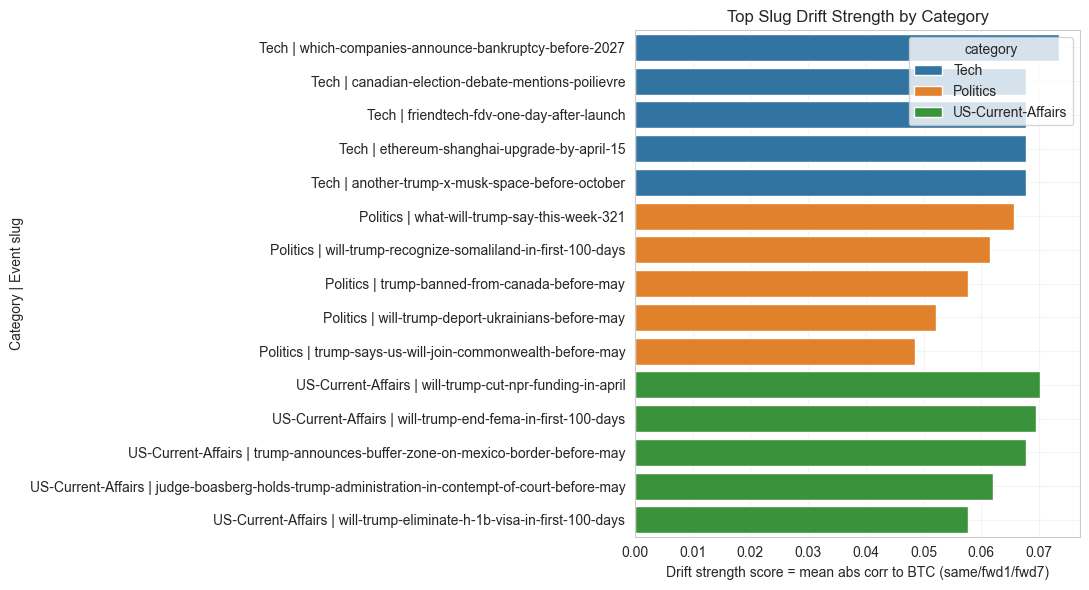

In [21]:
# Slug-level centrality drift analysis by category: Tech / Politics / US-Current-Affairs
if "kg_market_df" not in globals() or kg_market_df.empty:
    raise RuntimeError("kg_market_df is not available. Run Cell 8 first.")

target_categories = ["Tech", "Politics", "US-Current-Affairs"]
window_days = 30
top_n_per_category = 10
min_obs_per_slug = 30

work = kg_market_df.copy()
work["date"] = pd.to_datetime(work["date"]).dt.normalize()
work["category"] = work["category"].astype(str).str.strip()
work["event_slug"] = work["event_slug"].astype(str).str.strip()
work = work[
    work["category"].isin(target_categories)
    & (work["event_slug"] != "")
    & (work["event_slug"].str.lower() != "unknown")
]
if work.empty:
    raise RuntimeError("No rows available for target categories.")

slug_day = (
    work.groupby(["category", "date", "event_slug"], as_index=False)
    .agg(
        volume=("volume", "sum"),
        trade_count=("trade_count", "sum"),
        btc_return=("btc_return", "mean"),
    )
    .sort_values(["category", "date", "event_slug"])
)
slug_day["edge_weight"] = np.log1p(slug_day["volume"].clip(lower=0.0)) + 0.30 * np.log1p(slug_day["trade_count"].clip(lower=0.0))

centrality_rows = []
for category in target_categories:
    sub_cat = slug_day[slug_day["category"] == category].copy()
    if sub_cat.empty:
        continue

    all_dates = sorted(sub_cat["date"].unique())
    slug_list = sorted(sub_cat["event_slug"].unique())

    for end_date in all_dates:
        start_date = end_date - pd.Timedelta(days=window_days - 1)
        w = sub_cat[(sub_cat["date"] >= start_date) & (sub_cat["date"] <= end_date)]
        if w.empty:
            continue

        B = nx.Graph()
        for slug in slug_list:
            B.add_node(f"slug::{slug}", bipartite="slug", event_slug=slug)

        for _, r in w.iterrows():
            day_key = pd.to_datetime(r["date"]).strftime("%Y-%m-%d")
            day_node = f"day::{day_key}"
            slug_node = f"slug::{r['event_slug']}"
            if day_node not in B:
                B.add_node(day_node, bipartite="day", day=day_key)
            B.add_edge(slug_node, day_node, weight=float(r["edge_weight"]))

        if B.number_of_edges() == 0:
            cent_map = {slug: 0.0 for slug in slug_list}
        else:
            try:
                eig = nx.eigenvector_centrality(B, max_iter=4000, tol=1e-08, weight="weight")
                cent_map = {slug: float(eig.get(f"slug::{slug}", 0.0)) for slug in slug_list}
            except Exception:
                deg = nx.degree_centrality(B)
                cent_map = {slug: float(deg.get(f"slug::{slug}", 0.0)) for slug in slug_list}

        for slug in slug_list:
            centrality_rows.append({
                "category": category,
                "date": end_date,
                "event_slug": slug,
                "slug_centrality": float(cent_map.get(slug, 0.0)),
            })

slug_cent_df = pd.DataFrame(centrality_rows).sort_values(["category", "event_slug", "date"]).reset_index(drop=True)
slug_cent_df["slug_drift"] = slug_cent_df.groupby(["category", "event_slug"])["slug_centrality"].diff()
slug_cent_df["abs_slug_drift"] = slug_cent_df["slug_drift"].abs()

btc_daily = (
    work.groupby("date", as_index=False)
    .agg(btc_return=("btc_return", "mean"))
    .sort_values("date")
    .reset_index(drop=True)
)
btc_daily["btc_abs_return"] = btc_daily["btc_return"].abs()
btc_daily["btc_ret_fwd_1"] = btc_daily["btc_return"].shift(-1)
btc_daily["btc_ret_fwd_7"] = btc_daily["btc_return"].shift(-7)

slug_merged = slug_cent_df.merge(btc_daily, on="date", how="left")

summary_rows = []
for (category, slug), sub in slug_merged.groupby(["category", "event_slug"]):
    valid = sub[["slug_centrality", "slug_drift", "abs_slug_drift", "btc_return", "btc_ret_fwd_1", "btc_ret_fwd_7", "btc_abs_return"]].dropna()
    if len(valid) < min_obs_per_slug:
        continue

    corr_same = float(valid["slug_drift"].corr(valid["btc_return"]))
    corr_fwd1 = float(valid["slug_drift"].corr(valid["btc_ret_fwd_1"]))
    corr_fwd7 = float(valid["slug_drift"].corr(valid["btc_ret_fwd_7"]))
    drift_strength = np.nanmean([abs(corr_same), abs(corr_fwd1), abs(corr_fwd7)])

    q90 = float(valid["abs_slug_drift"].quantile(0.90))
    jump_days = valid[valid["abs_slug_drift"] >= q90]
    jump_mean_abs_btc = float(jump_days["btc_abs_return"].mean()) if len(jump_days) > 0 else np.nan

    summary_rows.append({
        "category": category,
        "event_slug": slug,
        "n_obs": int(len(valid)),
        "mean_centrality": float(valid["slug_centrality"].mean()),
        "mean_abs_drift": float(valid["abs_slug_drift"].mean()),
        "corr_drift_btc_same": corr_same,
        "corr_drift_btc_fwd1": corr_fwd1,
        "corr_drift_btc_fwd7": corr_fwd7,
        "drift_strength_score": float(drift_strength) if pd.notna(drift_strength) else np.nan,
        "jump_day_mean_abs_btc_ret": jump_mean_abs_btc,
    })

slug_drift_summary_df = pd.DataFrame(summary_rows)
if slug_drift_summary_df.empty:
    raise RuntimeError("No slug has enough observations for category-level slug drift analysis.")

print("Category-wise top centrality slugs and drift sensitivity:")
for category in target_categories:
    sub = slug_drift_summary_df[slug_drift_summary_df["category"] == category].copy()
    if sub.empty:
        print(f"- {category}: no eligible slugs")
        continue

    ranked = sub.sort_values(["mean_centrality", "drift_strength_score"], ascending=[False, False]).head(top_n_per_category)
    print(f"\n[{category}] Top {len(ranked)} slugs")
    display(ranked[[
        "event_slug",
        "mean_centrality",
        "mean_abs_drift",
        "drift_strength_score",
        "corr_drift_btc_same",
        "corr_drift_btc_fwd1",
        "corr_drift_btc_fwd7",
        "jump_day_mean_abs_btc_ret",
        "n_obs",
]])

# Compact visualization: top 5 drift-strength slugs in each category
plot_rows = []
for category in target_categories:
    sub = slug_drift_summary_df[slug_drift_summary_df["category"] == category].copy()
    if sub.empty:
        continue
    sub = sub.sort_values("drift_strength_score", ascending=False).head(5)
    plot_rows.append(sub)

if len(plot_rows) > 0:
    plot_df = pd.concat(plot_rows, ignore_index=True)
    plot_df["label"] = plot_df["category"] + " | " + plot_df["event_slug"]

    plt.figure(figsize=(11, 6))
    sns.barplot(data=plot_df, x="drift_strength_score", y="label", hue="category", dodge=False)
    plt.title("Top Slug Drift Strength by Category")
    plt.xlabel("Drift strength score = mean abs corr to BTC (same/fwd1/fwd7)")
    plt.ylabel("Category | Event slug")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()